# SafeSpan Bridge Analytics
## Predictive Maintenance for U.S. Bridge Infrastructure
### DATA 245 — Final Presentation Notebook

---

**Dataset:** National Bridge Inventory (NBI), 2018 – 2025
**Training data:** `nbi_train_2018.csv.gz` → `nbi_train_2024.csv.gz` (7 years × 600 K rows)
**Test data:** `nbi_test_2025.csv.gz` (600 K rows, held-out)

### Notebook road-map

| § | Section | Key Output |
|---|---------|-----------|
| 1 | Data Loading & Integration | Combined 4.8 M-row panel |
| 2 | Exploratory Data Analysis | Distribution & trend plots |
| 3 | Feature Engineering | 5 new domain features |
| 4 | Data Drift (PSI + JS) | Per-feature drift tables & plots |
| 5 | Target Drift | Condition-share trends 2018 → 2025 |
| 6 | Model Training (LightGBM) | Best classifier on 2018-2024 |
| 7 | 2025 Test Evaluation | Full metrics + safety-critical audit |
| 8 | SHAP Interpretability | Global + local feature importance |
| 9 | Model Performance Drift | Temporal hold-out evaluation |
| 10 | Survival Dataset | One row per bridge, time-to-event |
| 11 | Kaplan-Meier Analysis | Survival curves & log-rank tests |
| 12 | Cox Proportional Hazards | Hazard ratios per feature |
| 13 | Final Dashboard & Summary | Publication-ready summary figure |

---
**Install dependencies (run once if needed):**
```bash
pip install lightgbm lifelines shap imbalanced-learn pyarrow
```


## Section 0 — Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, time
import numpy as np
import pandas as pd
import matplotlib
# Use Agg backend only when running as a plain script (not inside Jupyter)
try:
    get_ipython()                        # noqa: F821 – defined in Jupyter kernels
except NameError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from scipy import stats
from scipy.spatial.distance import jensenshannon

# ── scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

# ── LightGBM ──────────────────────────────────────────────────────────────────
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print("LightGBM", lgb.__version__)
except Exception:
    LGBM_AVAILABLE = False
    print("NOTE: LightGBM unavailable — RandomForest fallback active")

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP", shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print("NOTE: SHAP not installed — interpretability section will be skipped")

# ── lifelines ─────────────────────────────────────────────────────────────────
try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.statistics import logrank_test
    LIFELINES_AVAILABLE = True
    print("lifelines available")
except ImportError:
    LIFELINES_AVAILABLE = False
    print("NOTE: lifelines not installed — survival analysis sections skipped")

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
})

CMAP = {
    "Critical": "#d62728",   # red
    "Poor":     "#ff7f0e",   # orange
    "Fair":     "#bcbd22",   # yellow-green
    "Good":     "#2ca02c",   # green
}
CLASS_ORDER = ["Critical", "Poor", "Fair", "Good"]
LABEL_MAP   = {c: i for i, c in enumerate(CLASS_ORDER)}  # Critical=0 … Good=3

os.makedirs("outputs",      exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

print("\nEnvironment ready")


LightGBM 4.6.0
SHAP 0.51.0
lifelines available

Environment ready


---
## Section 1 — Data Loading & Integration

Each year's NBI snapshot lives in a separate gzipped CSV.
We stream them one at a time to avoid peak-memory spikes, then concatenate.

**Train:** 2018 – 2024 &nbsp;|&nbsp; **Test:** 2025


In [2]:
# ── File manifest ─────────────────────────────────────────────────────────────
DATA_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else "."

TRAIN_FILES = {yr: os.path.join(DATA_DIR, f"nbi_train_{yr}.csv.gz")
               for yr in range(2018, 2025)}          # 2018 … 2024
TEST_FILE   = os.path.join(DATA_DIR, "nbi_test_2025.csv.gz")

# ── Leakage columns (raw condition ratings + derived evaluation scores) ────────
# These columns ARE the target or are directly computed from it —
# using them as features would be cheating.
LEAKAGE_COLS = [
    "DECK_COND_058",           # raw deck condition rating   ← target source
    "SUPERSTRUCTURE_COND_059", # raw superstructure rating   ← target source
    "SUBSTRUCTURE_COND_060",   # raw substructure rating     ← target source
    "CULVERT_COND_062",        # raw culvert rating          ← target source
    "STRUCTURAL_EVAL_067",     # FHWA-computed from ratings  ← derived
    "DECK_GEOMETRY_EVAL_068",  # derived evaluation          ← derived
    "UNDCLRENCE_EVAL_069",     # derived evaluation          ← derived
    "POSTING_EVAL_070",        # derived evaluation          ← derived
    "WATERWAY_EVAL_071",       # derived evaluation          ← derived
    "APPR_ROAD_EVAL_072",      # derived evaluation          ← derived
]

# Administrative / ID columns (kept only for joining, not as model features)
ID_COLS = ["STRUCTURE_NUMBER_008", "YEAR", "YEAR_BUILT_027",
           "PLACE_CODE_004", "YEAR_ADT_030"]

# ── Load helper ───────────────────────────────────────────────────────────────
def load_year(path: str, year: int) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df["YEAR"] = year          # ensure YEAR column is present
    return df

print("Loading training files …")
t0 = time.time()

train_frames = []
for yr, path in TRAIN_FILES.items():
    df_yr = load_year(path, yr)
    train_frames.append(df_yr)
    print(f"  {yr}: {len(df_yr):>7,} rows  |  BRIDGE_CONDITION: "
          f"{dict(df_yr['BRIDGE_CONDITION'].value_counts())}")

train_raw = pd.concat(train_frames, ignore_index=True)
print(f"\nTrain combined: {len(train_raw):,} rows  ({time.time()-t0:.1f}s)")

print("\nLoading test file (2025) …")
test_raw = load_year(TEST_FILE, 2025)
print(f"Test:           {len(test_raw):,} rows  |  "
      f"{dict(test_raw['BRIDGE_CONDITION'].value_counts())}")

print(f"\nColumns ({train_raw.shape[1]}): {list(train_raw.columns)}")


Loading training files …
  2018: 600,000 rows  |  BRIDGE_CONDITION: {'Fair': np.int64(337365), 'Poor': np.int64(134844), 'Good': np.int64(84208), 'Critical': np.int64(43583)}
  2019: 600,000 rows  |  BRIDGE_CONDITION: {'Fair': np.int64(324103), 'Poor': np.int64(127351), 'Good': np.int64(107363), 'Critical': np.int64(41183)}
  2020: 600,000 rows  |  BRIDGE_CONDITION: {'Fair': np.int64(312288), 'Good': np.int64(128093), 'Poor': np.int64(120761), 'Critical': np.int64(38858)}
  2021: 600,000 rows  |  BRIDGE_CONDITION: {'Fair': np.int64(300881), 'Good': np.int64(146382), 'Poor': np.int64(115704), 'Critical': np.int64(37033)}
  2022: 600,000 rows  |  BRIDGE_CONDITION: {'Fair': np.int64(284884), 'Good': np.int64(156866), 'Poor': np.int64(120260), 'Critical': np.int64(37990)}
  2023: 600,000 rows  |  BRIDGE_CONDITION: {'Fair': np.int64(261518), 'Good': np.int64(161058), 'Poor': np.int64(135141), 'Critical': np.int64(42283)}
  2024: 600,000 rows  |  BRIDGE_CONDITION: {'Fair': np.int64(237193), 

### 1.1 — Column summary


In [3]:
print("=" * 60)
print(" COLUMN INVENTORY")
print("=" * 60)
for col in train_raw.columns:
    dtype  = str(train_raw[col].dtype)
    nuniq  = train_raw[col].nunique()
    null_p = train_raw[col].isna().mean() * 100
    flag   = "[LEAKAGE]" if col in LEAKAGE_COLS else (
              "[ID/META]" if col in ID_COLS else
              "[TARGET]"  if col == "BRIDGE_CONDITION" else
              "[FEATURE]")
    print(f"  {flag:12s}  {col:<35s}  dtype={dtype:<8s}  nuniq={nuniq:>7,}  null={null_p:.1f}%")


 COLUMN INVENTORY
  [ID/META]     YEAR                                 dtype=int64     nuniq=      7  null=0.0%
  [ID/META]     STRUCTURE_NUMBER_008                 dtype=int64     nuniq=600,000  null=0.0%
  [FEATURE]     STATE_CODE_001                       dtype=int64     nuniq=     51  null=0.0%
  [FEATURE]     COUNTY_CODE_003                      dtype=int64     nuniq=    199  null=0.0%
  [ID/META]     PLACE_CODE_004                       dtype=int64     nuniq= 99,660  null=0.0%
  [FEATURE]     RECORD_TYPE_005A                     dtype=int64     nuniq=      1  null=0.0%
  [FEATURE]     LAT_016                              dtype=float64   nuniq=592,637  null=0.0%
  [FEATURE]     LONG_017                             dtype=float64   nuniq=596,782  null=0.0%
  [FEATURE]     MAINTENANCE_021                      dtype=int64     nuniq=     11  null=0.0%
  [FEATURE]     OWNER_022                            dtype=int64     nuniq=     11  null=0.0%
  [FEATURE]     FUNCTIONAL_CLASS_026      

### 1.2 — Correlation Filter

Pearson correlation filter at 0.90 — matches midterm preprocessing.
Removes one column from each highly-correlated pair before modelling.
Known pairs: INVENTORY_RATING ↔ OPERATING_RATING (~0.986),
WORK_DONE_BY_076 ↔ WORK_PROPOSED_075 (~0.953).


In [4]:
# Pearson correlation filter at 0.90 — matches midterm preprocessing
# Removes one column from each highly-correlated pair
# Pairs found: INVENTORY_RATING ↔ OPERATING_RATING (0.986)
#              WORK_DONE_BY_076 ↔ WORK_PROPOSED_075 (0.953)
#              BRIDGE_AGE ↔ YEAR_BUILT (1.000 — YEAR_BUILT already excluded)

def apply_correlation_filter(df, feature_cols, threshold=0.90):
    X = df[feature_cols].select_dtypes(include=[np.number])
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns
                 if any(upper[col] > threshold)]
    kept = [c for c in feature_cols if c not in drop_cols]
    print(f"Correlation filter (>{threshold}): dropped {len(drop_cols)} cols")
    for c in drop_cols:
        partner = upper[c][upper[c] > threshold].idxmax()
        print(f"  Dropped {c} (corr={upper[c].max():.3f} with {partner})")
    return kept, drop_cols


---
## Section 2 — Exploratory Data Analysis

Before modelling we examine:
1. Class balance across the full 4.8 M-row dataset
2. How bridge condition has evolved year-over-year (target drift preview)
3. Condition by bridge material, age, geography, and traffic


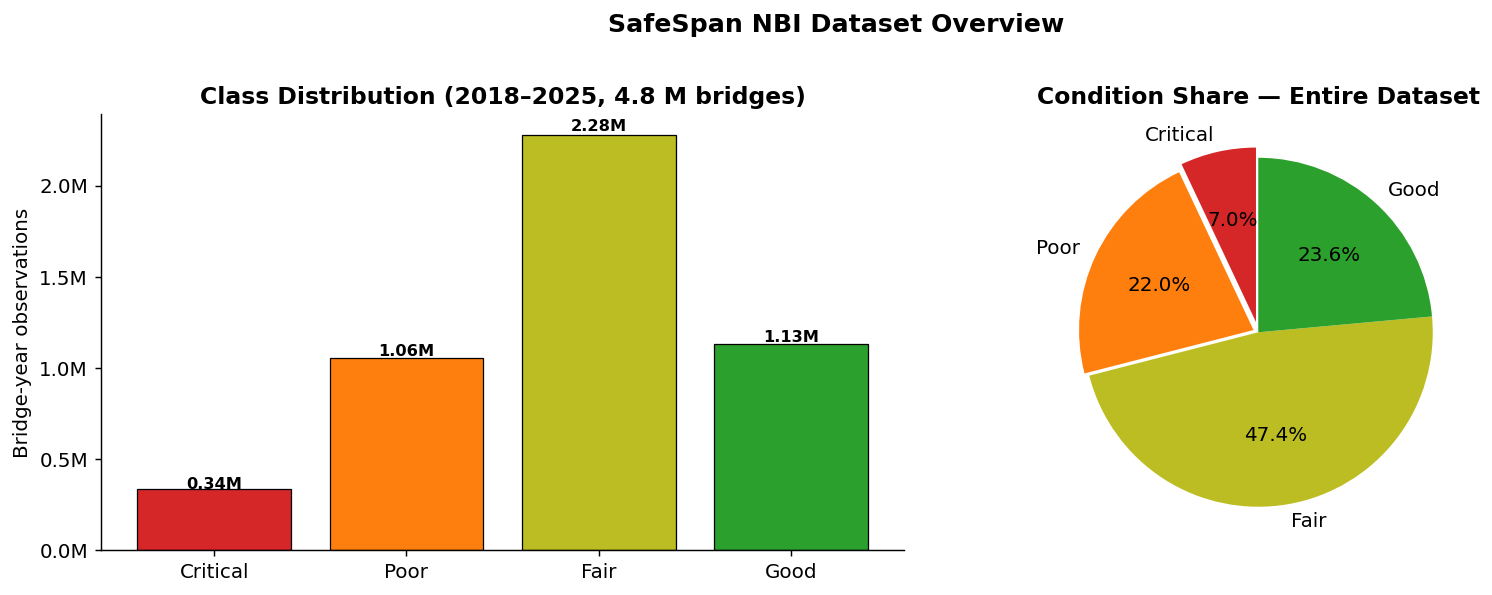


Class counts:
BRIDGE_CONDITION
Critical     336569
Poor        1055395
Fair        2277380
Good        1130656


In [5]:
# ── 2.1 Overall class distribution ───────────────────────────────────────────
all_data = pd.concat([train_raw, test_raw], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = all_data["BRIDGE_CONDITION"].value_counts().reindex(CLASS_ORDER)
bars = axes[0].bar(CLASS_ORDER, counts.values,
                   color=[CMAP[c] for c in CLASS_ORDER],
                   edgecolor="black", linewidth=0.7)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f"{val/1e6:.2f}M", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Class Distribution (2018–2025, 4.8 M bridges)")
axes[0].set_ylabel("Bridge-year observations")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].pie(counts.values, labels=CLASS_ORDER, autopct="%1.1f%%",
            colors=[CMAP[c] for c in CLASS_ORDER],
            startangle=90, explode=[0.06, 0.03, 0, 0])
axes[1].set_title("Condition Share — Entire Dataset")

plt.suptitle("SafeSpan NBI Dataset Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs/plots/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nClass counts:\n{counts.to_string()}")


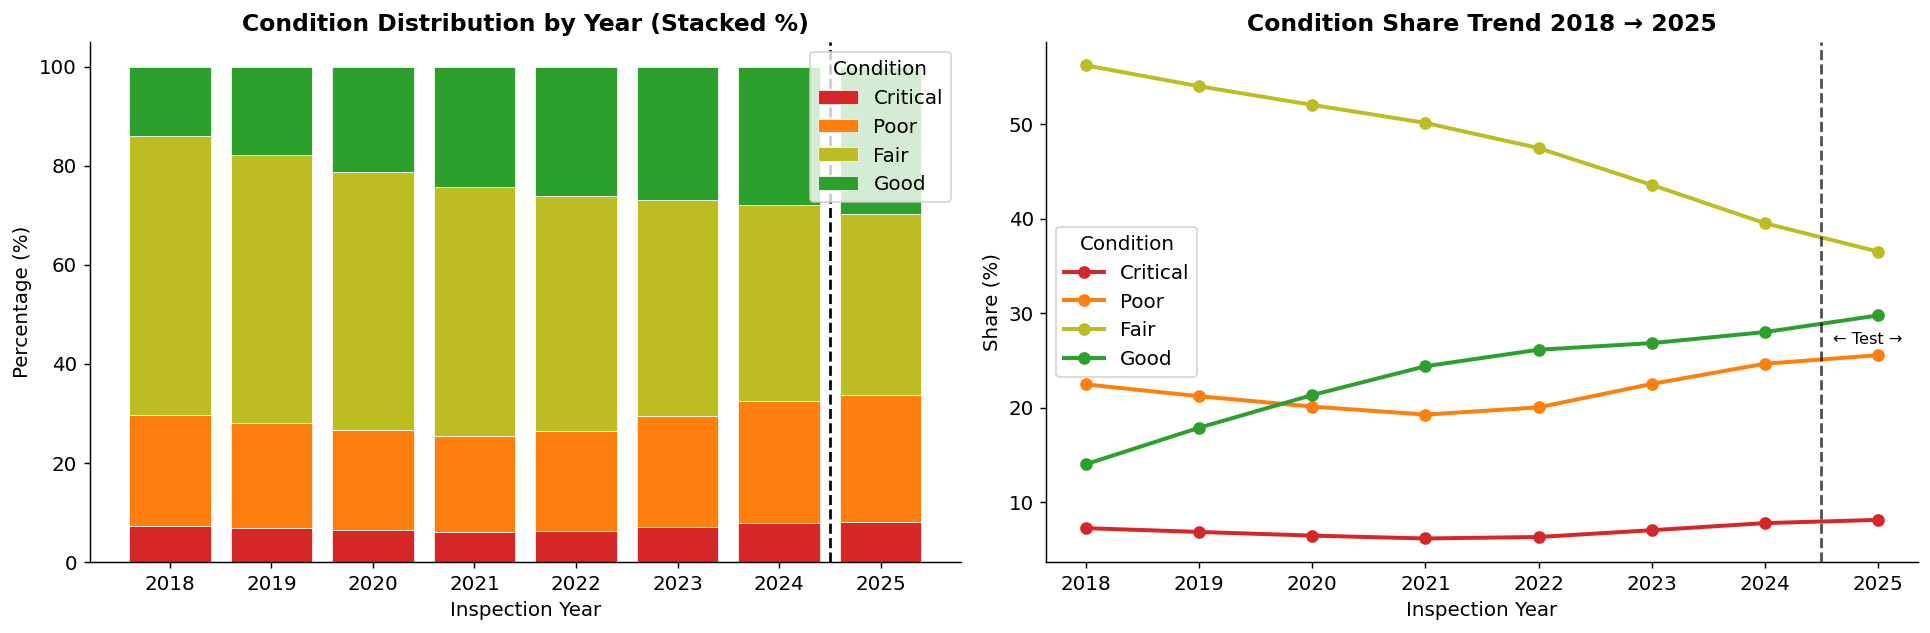


Yearly condition distribution (%):
BRIDGE_CONDITION  Critical   Poor   Fair   Good
YEAR                                           
2018                  7.26  22.47  56.23  14.03
2019                  6.86  21.23  54.02  17.89
2020                  6.48  20.13  52.05  21.35
2021                  6.17  19.28  50.15  24.40
2022                  6.33  20.04  47.48  26.14
2023                  7.05  22.52  43.59  26.84
2024                  7.80  24.66  39.53  28.01
2025                  8.14  25.56  36.52  29.77


In [6]:
# ── 2.2 Condition trends by year (target drift preview) ──────────────────────
yearly_pct = (
    all_data.groupby(["YEAR", "BRIDGE_CONDITION"])
            .size()
            .reset_index(name="count")
)
yearly_pct["pct"] = yearly_pct.groupby("YEAR")["count"].transform(
    lambda x: x / x.sum() * 100
)
pivot = (yearly_pct
         .pivot(index="YEAR", columns="BRIDGE_CONDITION", values="pct")
         .reindex(columns=CLASS_ORDER)
         .fillna(0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar
bottom = np.zeros(len(pivot))
for cond in CLASS_ORDER:
    axes[0].bar(pivot.index, pivot[cond], bottom=bottom,
                color=CMAP[cond], label=cond, edgecolor="white", linewidth=0.4)
    bottom += pivot[cond].values
axes[0].set_title("Condition Distribution by Year (Stacked %)")
axes[0].set_xlabel("Inspection Year")
axes[0].set_ylabel("Percentage (%)")
axes[0].legend(title="Condition", loc="upper right")
axes[0].axvline(2024.5, color="black", linestyle="--", linewidth=1.5, label="Train | Test")

# Line chart
for cond in CLASS_ORDER:
    axes[1].plot(pivot.index, pivot[cond],
                 marker="o", color=CMAP[cond], label=cond, linewidth=2.2)
axes[1].axvline(2024.5, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1].set_title("Condition Share Trend 2018 → 2025")
axes[1].set_xlabel("Inspection Year")
axes[1].set_ylabel("Share (%)")
axes[1].legend(title="Condition")
axes[1].text(2024.6, pivot["Good"].max()*0.9, "← Test →", fontsize=9, color="black")

plt.tight_layout()
plt.savefig("outputs/plots/02_yearly_condition_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nYearly condition distribution (%):")
print(pivot.round(2).to_string())


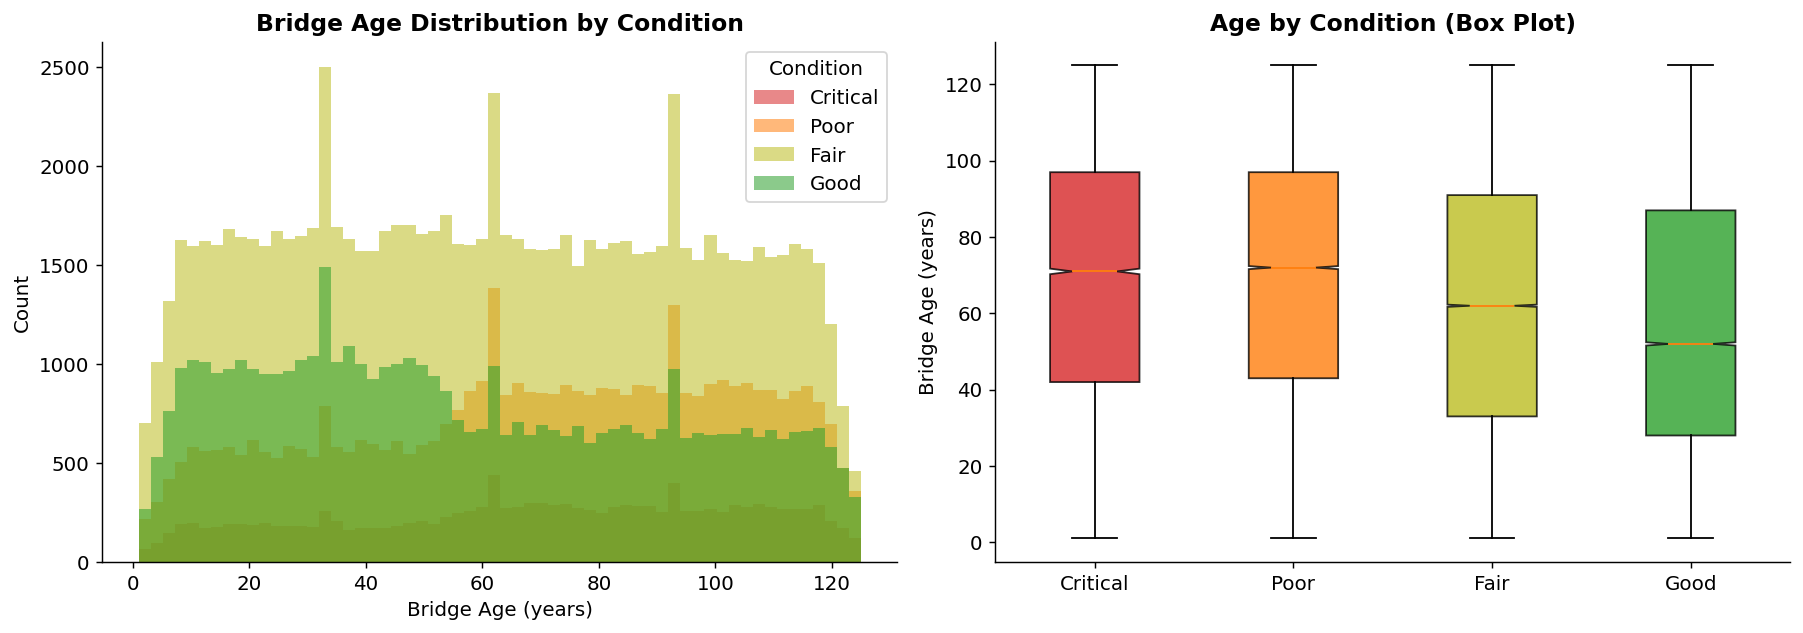

Median age by condition:
  Critical  : 71 years
  Poor      : 72 years
  Fair      : 62 years
  Good      : 52 years


In [7]:
# ── 2.3 Bridge age distribution by condition ─────────────────────────────────
sample_eda = all_data.sample(200_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cond in CLASS_ORDER:
    data = sample_eda[sample_eda["BRIDGE_CONDITION"] == cond]["BRIDGE_AGE_AT_INSPECTION"]
    axes[0].hist(data, bins=60, alpha=0.55, label=cond,
                 color=CMAP[cond], edgecolor="none")
axes[0].set_xlabel("Bridge Age (years)")
axes[0].set_ylabel("Count")
axes[0].set_title("Bridge Age Distribution by Condition")
axes[0].legend(title="Condition")

bp_data = [sample_eda[sample_eda["BRIDGE_CONDITION"] == c]["BRIDGE_AGE_AT_INSPECTION"]
           for c in CLASS_ORDER]
bp = axes[1].boxplot(bp_data, labels=CLASS_ORDER, patch_artist=True, notch=True)
for patch, cond in zip(bp["boxes"], CLASS_ORDER):
    patch.set_facecolor(CMAP[cond])
    patch.set_alpha(0.8)
axes[1].set_ylabel("Bridge Age (years)")
axes[1].set_title("Age by Condition (Box Plot)")

plt.tight_layout()
plt.savefig("outputs/plots/03_age_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()

# Print median ages
print("Median age by condition:")
for cond in CLASS_ORDER:
    med = sample_eda[sample_eda["BRIDGE_CONDITION"] == cond]["BRIDGE_AGE_AT_INSPECTION"].median()
    print(f"  {cond:<10s}: {med:.0f} years")


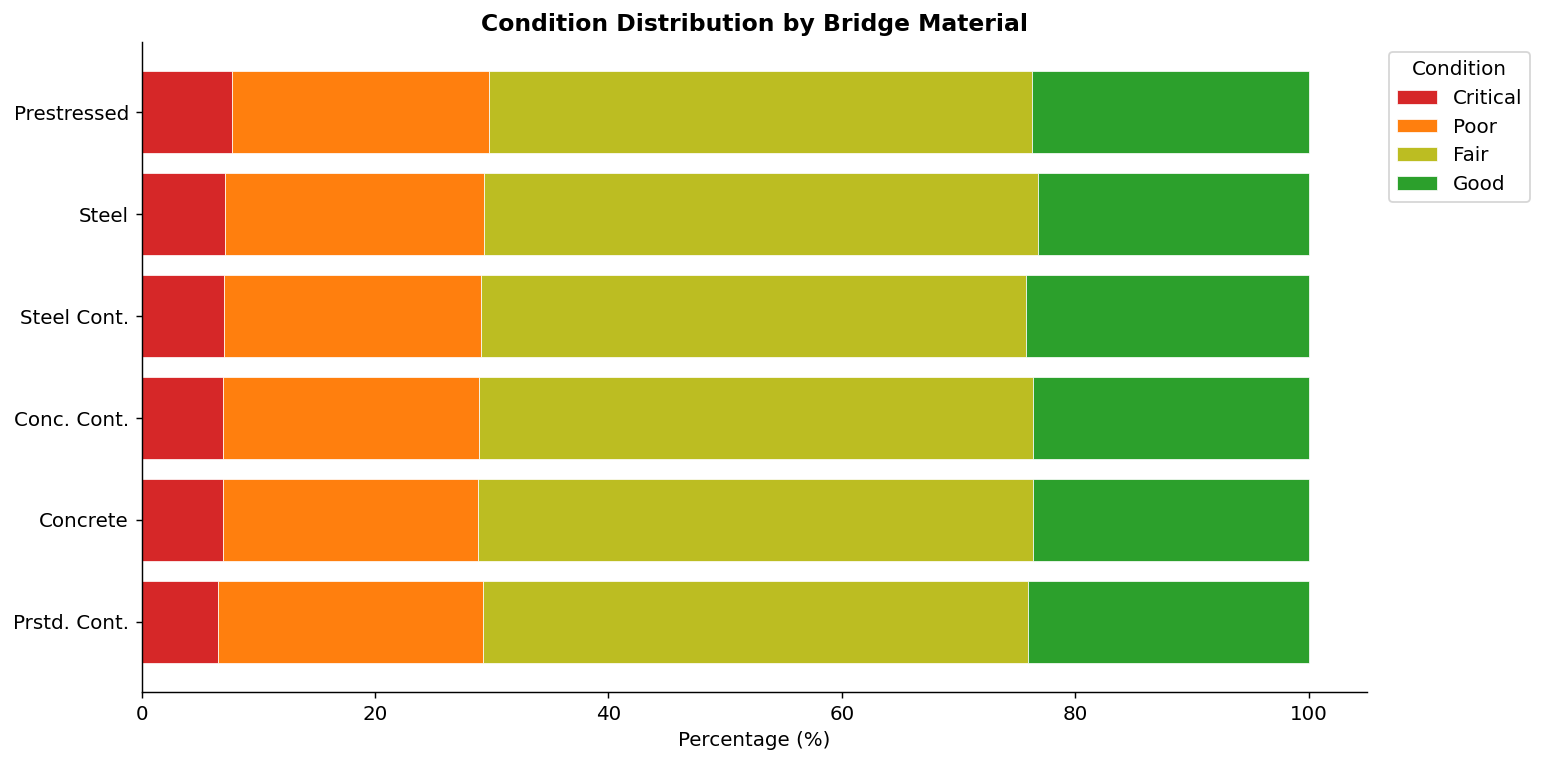

In [8]:
# ── 2.4 Condition by bridge material (STRUCTURE_KIND_043) ─────────────────────
KIND_LABELS = {
    1: "Concrete", 2: "Conc. Cont.", 3: "Steel", 4: "Steel Cont.",
    5: "Prestressed", 6: "Prstd. Cont.", 7: "Wood/Timber",
    8: "Masonry", 9: "Alum/Iron", 0: "Other",
}
sample_eda["Material"] = sample_eda["STRUCTURE_KIND_043"].map(KIND_LABELS).fillna("Other")

ct = pd.crosstab(sample_eda["Material"], sample_eda["BRIDGE_CONDITION"],
                 normalize="index")[CLASS_ORDER] * 100
ct = ct.sort_values("Critical", ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(ct))
for cond in CLASS_ORDER:
    ax.barh(ct.index, ct[cond], left=bottom,
            color=CMAP[cond], label=cond, edgecolor="white", linewidth=0.4)
    bottom += ct[cond].values
ax.set_xlabel("Percentage (%)")
ax.set_title("Condition Distribution by Bridge Material")
ax.legend(title="Condition", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("outputs/plots/04_condition_by_material.png", dpi=150, bbox_inches="tight")
plt.show()


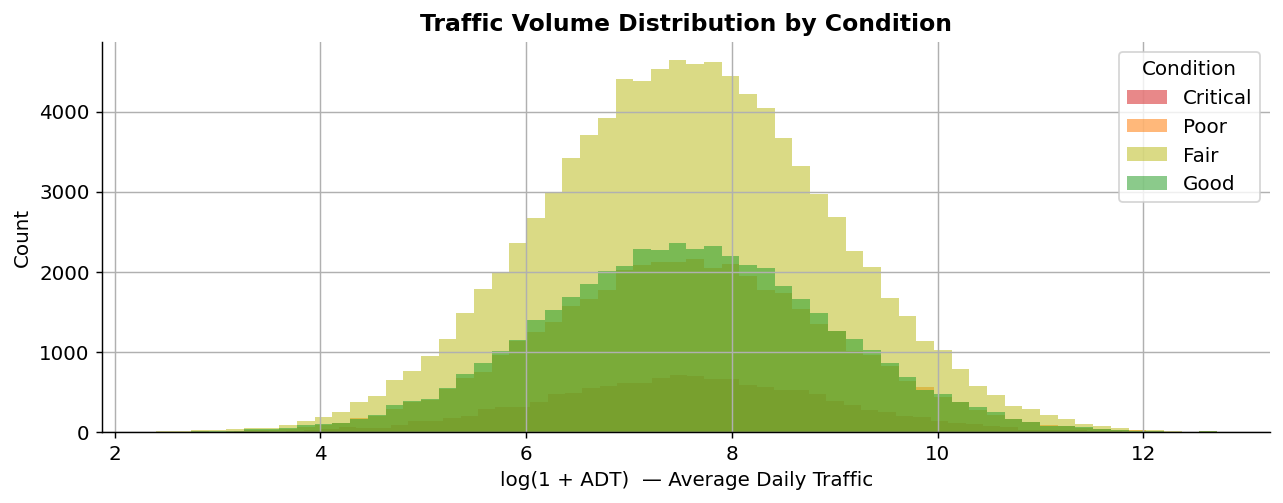

In [9]:
# ── 2.5 Condition by traffic volume (ADT) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for cond in CLASS_ORDER:
    vals = np.log1p(sample_eda[sample_eda["BRIDGE_CONDITION"] == cond]["ADT_029"])
    vals.hist(bins=60, alpha=0.55, ax=ax, label=cond, color=CMAP[cond])
ax.set_xlabel("log(1 + ADT)  — Average Daily Traffic")
ax.set_ylabel("Count")
ax.set_title("Traffic Volume Distribution by Condition")
ax.legend(title="Condition")
plt.tight_layout()
plt.savefig("outputs/plots/05_adt_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()


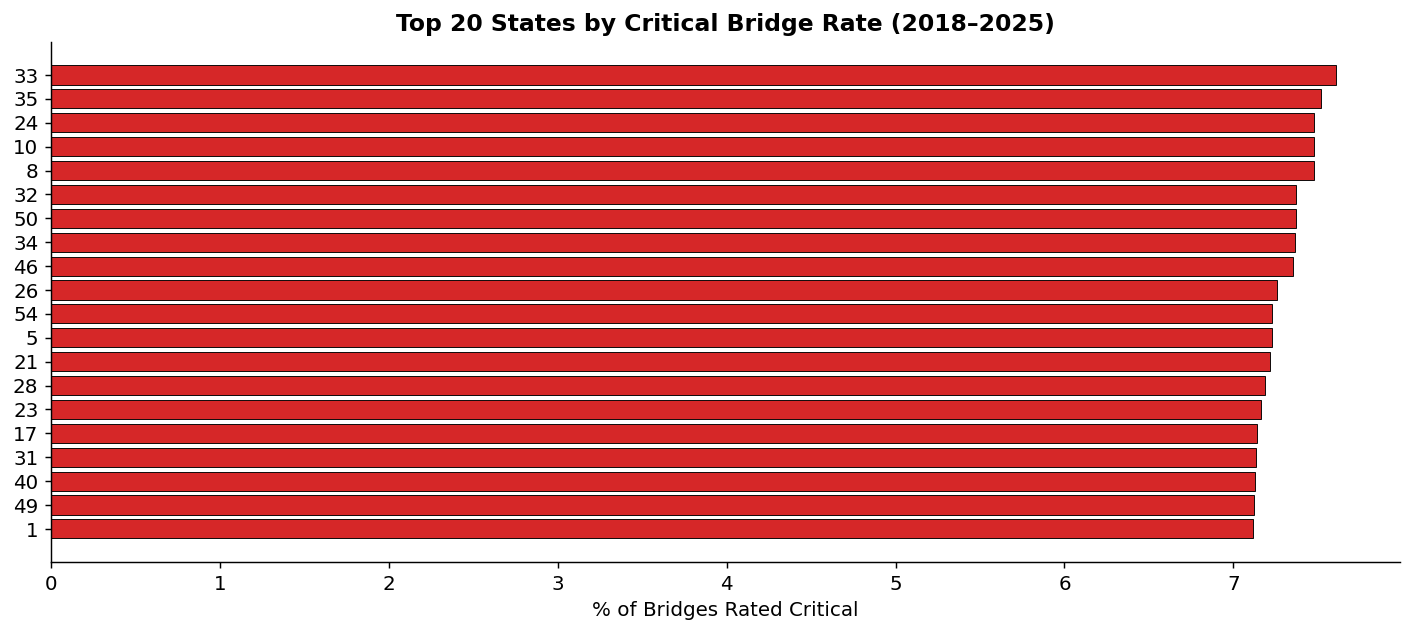

In [10]:
# ── 2.6 Top 20 states by Critical rate ───────────────────────────────────────
state_crit = (
    all_data.groupby("STATE_CODE_001")["BRIDGE_CONDITION"]
            .apply(lambda x: (x == "Critical").mean() * 100)
            .sort_values(ascending=False)
            .head(20)
)
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(state_crit.index[::-1].astype(str), state_crit.values[::-1],
        color=CMAP["Critical"], edgecolor="black", linewidth=0.5)
ax.set_xlabel("% of Bridges Rated Critical")
ax.set_title("Top 20 States by Critical Bridge Rate (2018–2025)")
plt.tight_layout()
plt.savefig("outputs/plots/06_state_critical_rate.png", dpi=150, bbox_inches="tight")
plt.show()


### Note on Missing Midterm Features

`SCOUR_CRITICAL_113` and `INSPECT_FREQ_MONTHS_091` were top SHAP features in
the midterm benchmark but are **not present** in the pre-processed NBI gz files
(those columns exist only in the full 139-column raw NBI).
`AGE_X_SPANS` (below) captures the same compounded structural-fatigue hypothesis
using available columns.


---
## Section 3 — Feature Engineering

We create seven new domain features that capture physical and operational
characteristics not directly available as raw columns:

| Feature | Formula | Interpretation |
|---------|---------|----------------|
| `TRAFFIC_DENSITY` | ADT / span length | Bridges of similar length serving very different traffic volumes |
| `AGE_TO_SPAN_RATIO` | age / max-span length | Structural stress per unit length over time |
| `DECK_UTILISATION` | deck width / span length | Wider decks on shorter spans = overloaded geometry |
| `LOG_ADT` | log₁₊(ADT) | Compresses the ADT distribution's heavy right tail |
| `RATING_DIFF` | operating rating − inventory rating | Gap signals how close a bridge is to its safe limit |


Engineered feature stats (training set):
                       mean      std    min       max
TRAFFIC_DENSITY     172.801  363.648  0.642  2413.478
AGE_TO_SPAN_RATIO     4.514    3.944  0.160    18.000
DECK_UTILISATION      0.948    0.710  0.114     3.550
LOG_ADT               7.547    1.399  2.398    12.701
RATING_DIFF          18.739    8.984  3.000    40.500
AGE_X_SPANS         234.042  319.133  1.000  2356.000
WORK_PROPOSED_FLAG    3.064   10.492  0.000    46.000


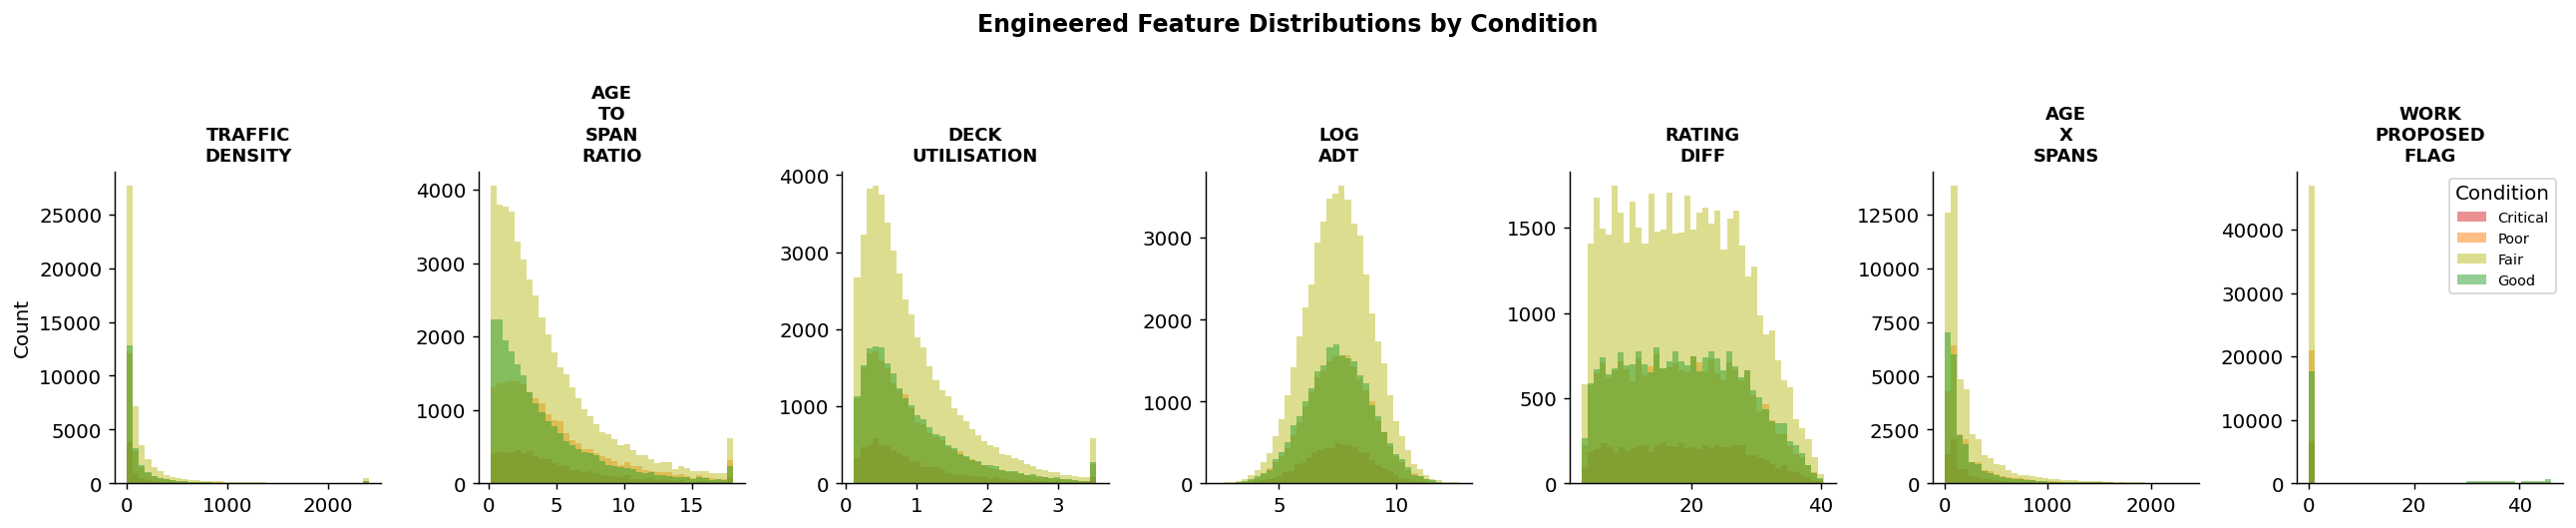

In [11]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add domain-engineered features. Operates on a copy."""
    df = df.copy()

    # Traffic per unit length
    df["TRAFFIC_DENSITY"]  = df["ADT_029"] / df["STRUCTURE_LEN_MT_049"].replace(0, np.nan)

    # Age relative to structural scale
    df["AGE_TO_SPAN_RATIO"] = (df["BRIDGE_AGE_AT_INSPECTION"]
                               / df["MAX_SPAN_LEN_MT_048"].replace(0, np.nan))

    # Deck width relative to span length
    df["DECK_UTILISATION"]  = (df["DECK_WIDTH_MT_052"]
                               / df["MAX_SPAN_LEN_MT_048"].replace(0, np.nan))

    # Log-ADT (stabilises the heavy-right tail)
    df["LOG_ADT"]           = np.log1p(df["ADT_029"])

    # Gap between operating and inventory rating
    df["RATING_DIFF"]       = df["OPERATING_RATING_064"] - df["INVENTORY_RATING_066"]

    # Structural stress interaction: age × number of main spans
    # Analogous to AGE_X_SCOUR from midterm (SCOUR_CRITICAL_113 not in
    # pre-processed files — this captures cumulative structural fatigue)
    df["AGE_X_SPANS"] = (df["BRIDGE_AGE_AT_INSPECTION"]
                         * df["MAIN_UNIT_SPANS_045"].replace(0, np.nan))

    # Time since last work was proposed (proxy for maintenance lag)
    df["WORK_PROPOSED_FLAG"] = pd.to_numeric(
        df["WORK_PROPOSED_075"], errors="coerce").fillna(0)

    # Clip extreme outliers from ratio features
    for col in ["TRAFFIC_DENSITY", "AGE_TO_SPAN_RATIO", "DECK_UTILISATION"]:
        if col in df.columns:
            lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
            df[col] = df[col].clip(lo, hi)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df


train_eng = engineer_features(train_raw)
test_eng  = engineer_features(test_raw)

ENG_FEATURES = ["TRAFFIC_DENSITY", "AGE_TO_SPAN_RATIO",
                "DECK_UTILISATION", "LOG_ADT", "RATING_DIFF",
                "AGE_X_SPANS", "WORK_PROPOSED_FLAG"]

print("Engineered feature stats (training set):")
print(train_eng[ENG_FEATURES].describe().T[["mean","std","min","max"]].round(3).to_string())

# ──── Quick visualisation of engineered features ──────────────────────────────
fig, axes = plt.subplots(1, len(ENG_FEATURES), figsize=(20, 4))
sample_eng = train_eng.sample(100_000, random_state=42)
for ax, feat in zip(axes, ENG_FEATURES):
    for cond in CLASS_ORDER:
        sub = sample_eng[sample_eng["BRIDGE_CONDITION"] == cond][feat].dropna()
        ax.hist(sub, bins=40, alpha=0.5, label=cond, color=CMAP[cond])
    ax.set_title(feat.replace("_", "\n"), fontsize=10)
    ax.set_xlabel("")
axes[0].set_ylabel("Count")
axes[-1].legend(title="Condition", fontsize=8)
plt.suptitle("Engineered Feature Distributions by Condition", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs/plots/07_engineered_features.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 4 — Data Drift Analysis

**Data drift** occurs when the statistical distribution of input features
changes between the training period and deployment.
We compare each year (2019–2025) against the 2018 baseline using:

- **Population Stability Index (PSI)** for numeric features
  PSI < 0.10 → stable &nbsp;|&nbsp; 0.10–0.25 → moderate drift &nbsp;|&nbsp; ≥ 0.25 → significant
- **Jensen-Shannon distance** for categorical features
  JS < 0.05 → low &nbsp;|&nbsp; 0.05–0.15 → moderate &nbsp;|&nbsp; > 0.15 → high


In [12]:
# ── PSI helper ────────────────────────────────────────────────────────────────
def compute_psi(base: pd.Series, comp: pd.Series, n_bins: int = 10) -> float:
    """Population Stability Index. Returns np.nan on failure."""
    base, comp = base.dropna().values, comp.dropna().values
    if len(base) < 100 or len(comp) < 100:
        return np.nan
    try:
        bp = np.unique(np.percentile(base, np.linspace(0, 100, n_bins + 1)))
    except Exception:
        return np.nan
    if len(bp) < 3:
        return np.nan
    bp[0] -= 1e-9;  bp[-1] += 1e-9
    base_ct, _ = np.histogram(base, bins=bp)
    comp_ct, _ = np.histogram(comp, bins=bp)
    eps = 1e-6
    bp_pct = np.where(base_ct == 0, eps, base_ct / base_ct.sum())
    cp_pct = np.where(comp_ct == 0, eps, comp_ct / comp_ct.sum())
    return float(np.sum((cp_pct - bp_pct) * np.log(cp_pct / bp_pct)))


def psi_level(v):
    if np.isnan(v):  return "unknown"
    if v < 0.10:     return "stable"
    if v < 0.25:     return "moderate"
    return "significant"


# ── JS distance helper ────────────────────────────────────────────────────────
def compute_js(base: pd.Series, comp: pd.Series) -> float:
    base, comp = base.dropna().astype(str), comp.dropna().astype(str)
    if len(base) < 30 or len(comp) < 30:
        return np.nan
    cats = list(set(base.unique()) | set(comp.unique()))
    p = np.array([base.value_counts().get(c, 0) for c in cats], dtype=float)
    q = np.array([comp.value_counts().get(c, 0) for c in cats], dtype=float)
    p /= p.sum();  q /= q.sum()
    return float(jensenshannon(p, q))


def js_level(v):
    if np.isnan(v):  return "unknown"
    if v < 0.05:     return "low"
    if v < 0.15:     return "moderate"
    return "high"


In [13]:
# ── Numeric drift features ────────────────────────────────────────────────────
NUMERIC_DRIFT_COLS = [
    "BRIDGE_AGE_AT_INSPECTION", "ADT_029", "LOG_ADT",
    "OPERATING_RATING_064", "INVENTORY_RATING_066", "RATING_DIFF",
    "TRAFFIC_DENSITY", "AGE_TO_SPAN_RATIO", "MAX_SPAN_LEN_MT_048",
    "STRUCTURE_LEN_MT_049", "DECK_WIDTH_MT_052",
]
NUMERIC_DRIFT_COLS = [c for c in NUMERIC_DRIFT_COLS
                      if c in train_eng.columns or c in test_eng.columns]

# ── Categorical drift features ─────────────────────────────────────────────────
CAT_DRIFT_COLS = ["STRUCTURE_KIND_043", "STRUCTURE_TYPE_044",
                  "STATE_CODE_001",     "FUNCTIONAL_CLASS_026",
                  "MAINTENANCE_021",    "OWNER_022"]
CAT_DRIFT_COLS = [c for c in CAT_DRIFT_COLS if c in train_eng.columns]

# ── Compute PSI: 2018 baseline vs each later year ────────────────────────────
all_eng = pd.concat([train_eng, test_eng], ignore_index=True)
baseline = all_eng[all_eng["YEAR"] == 2018]
compare_years = sorted(all_eng["YEAR"].unique())

psi_records = []
for yr in compare_years:
    if yr == 2018:
        continue
    comp = all_eng[all_eng["YEAR"] == yr]
    for feat in NUMERIC_DRIFT_COLS:
        if feat not in all_eng.columns:
            continue
        psi = compute_psi(baseline[feat], comp[feat])
        psi_records.append({"feature": feat, "year": yr,
                            "psi": psi, "level": psi_level(psi)})

psi_df = pd.DataFrame(psi_records)
psi_df.to_csv("outputs/psi_numeric_drift.csv", index=False)
print("Saved: outputs/psi_numeric_drift.csv")

avg_psi = (psi_df.groupby("feature")["psi"]
                 .mean()
                 .sort_values(ascending=False))
print("\nAverage PSI by feature (vs 2018 baseline):")
print(avg_psi.round(4).to_string())


Saved: outputs/psi_numeric_drift.csv

Average PSI by feature (vs 2018 baseline):
feature
BRIDGE_AGE_AT_INSPECTION    0.0206
AGE_TO_SPAN_RATIO           0.0184
ADT_029                     0.0021
LOG_ADT                     0.0021
TRAFFIC_DENSITY             0.0012
RATING_DIFF                 0.0000
INVENTORY_RATING_066        0.0000
OPERATING_RATING_064        0.0000
DECK_WIDTH_MT_052           0.0000
MAX_SPAN_LEN_MT_048         0.0000
STRUCTURE_LEN_MT_049        0.0000


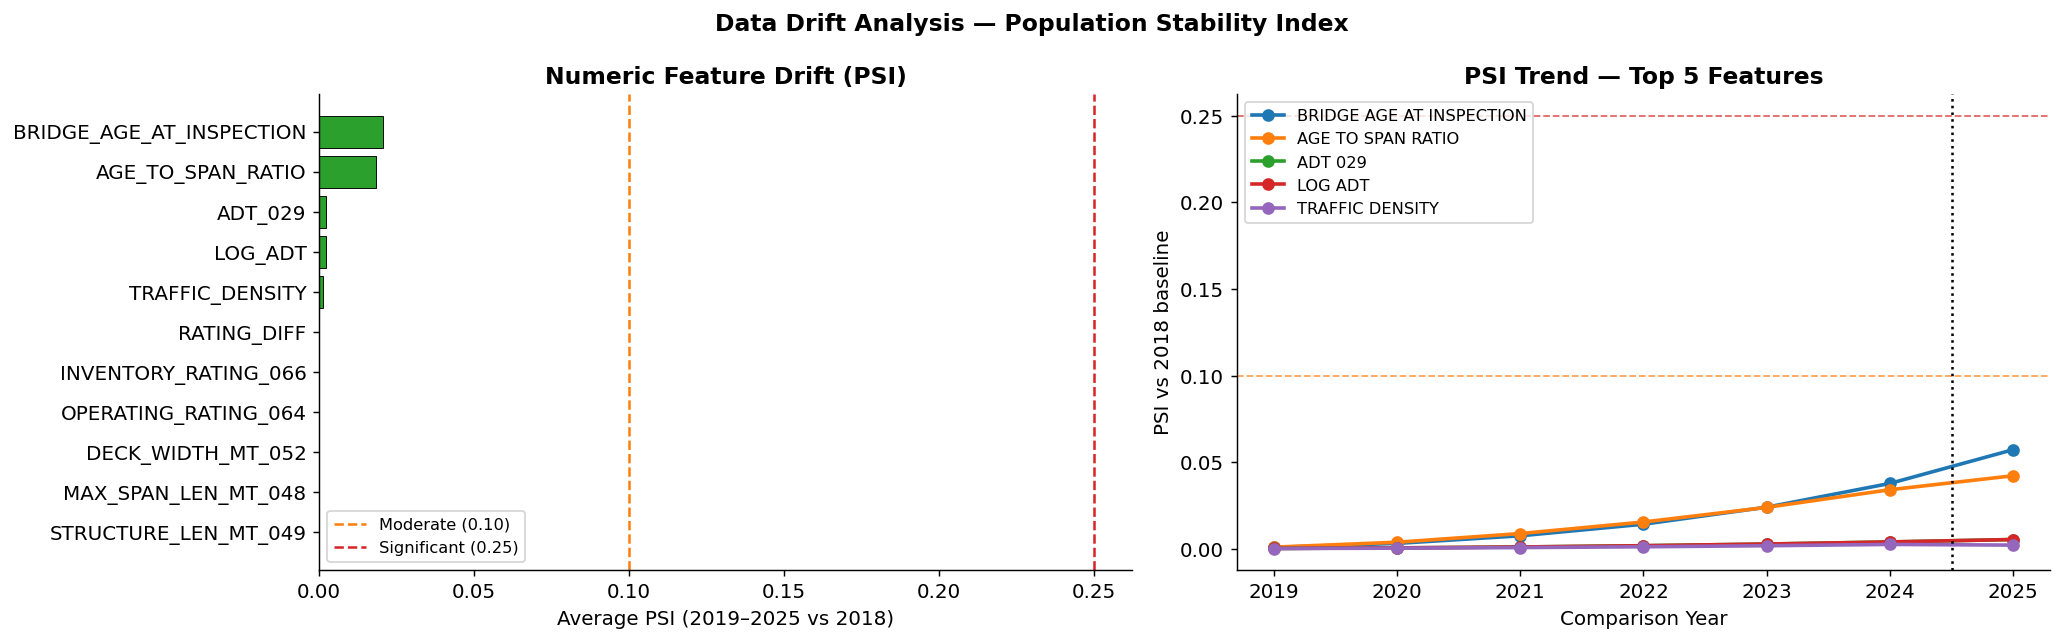

In [14]:
# ── PSI visualisation ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: average PSI bar
bar_colors = ["#d62728" if v >= 0.25 else "#ff7f0e" if v >= 0.10 else "#2ca02c"
              for v in avg_psi.values]
axes[0].barh(avg_psi.index[::-1], avg_psi.values[::-1],
             color=bar_colors[::-1], edgecolor="black", linewidth=0.5)
axes[0].axvline(0.10, color="#ff7f0e", linestyle="--", lw=1.4, label="Moderate (0.10)")
axes[0].axvline(0.25, color="#d62728", linestyle="--", lw=1.4, label="Significant (0.25)")
axes[0].set_xlabel("Average PSI (2019–2025 vs 2018)")
axes[0].set_title("Numeric Feature Drift (PSI)")
axes[0].legend(fontsize=9)

# Right: PSI trend for top 5 drifting features
top5 = avg_psi.head(5).index.tolist()
for feat in top5:
    sub = psi_df[psi_df["feature"] == feat].sort_values("year")
    axes[1].plot(sub["year"], sub["psi"],
                 marker="o", label=feat.replace("_", " "), linewidth=2)
axes[1].axhline(0.10, color="#ff7f0e", linestyle="--", lw=1, alpha=0.7)
axes[1].axhline(0.25, color="#d62728", linestyle="--", lw=1, alpha=0.7)
axes[1].axvline(2024.5, color="black", linestyle=":", lw=1.4)
axes[1].set_xlabel("Comparison Year")
axes[1].set_ylabel("PSI vs 2018 baseline")
axes[1].set_title("PSI Trend — Top 5 Features")
axes[1].legend(fontsize=9)

plt.suptitle("Data Drift Analysis — Population Stability Index", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/08_psi_drift.png", dpi=150, bbox_inches="tight")
plt.show()


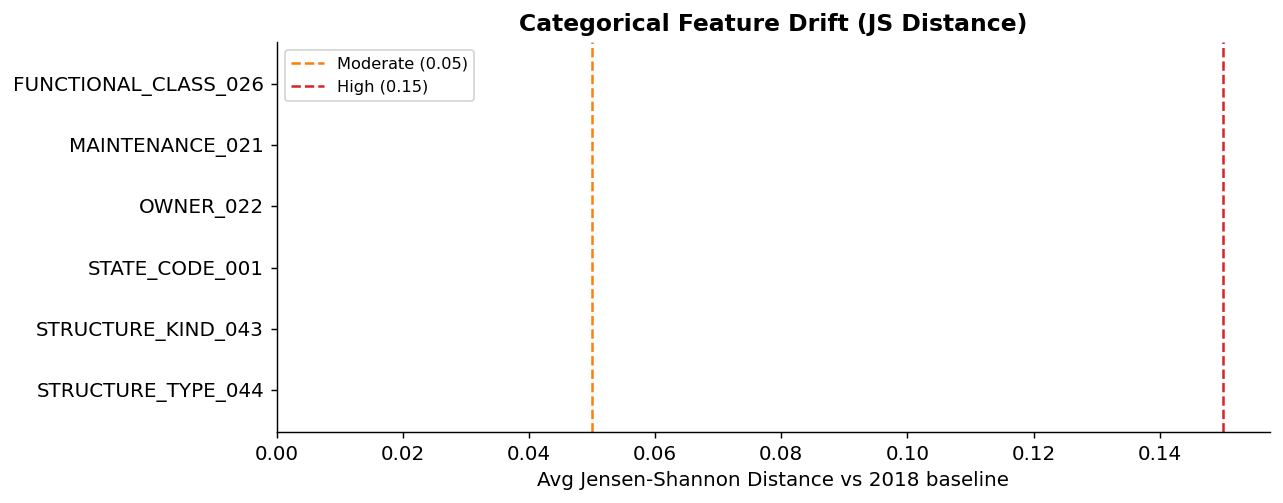

Saved: outputs/js_categorical_drift.csv

Average JS distance by feature:
feature
FUNCTIONAL_CLASS_026    0.0
MAINTENANCE_021         0.0
OWNER_022               0.0
STATE_CODE_001          0.0
STRUCTURE_KIND_043      0.0
STRUCTURE_TYPE_044      0.0


In [15]:
# ── Categorical drift ─────────────────────────────────────────────────────────
js_records = []
for yr in compare_years:
    if yr == 2018:
        continue
    comp = all_eng[all_eng["YEAR"] == yr]
    for feat in CAT_DRIFT_COLS:
        js = compute_js(baseline[feat], comp[feat])
        js_records.append({"feature": feat, "year": yr,
                           "js_distance": js, "level": js_level(js)})

js_df = pd.DataFrame(js_records)
js_df.to_csv("outputs/js_categorical_drift.csv", index=False)

avg_js = (js_df.groupby("feature")["js_distance"]
               .mean()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
jcolors = ["#d62728" if v > 0.15 else "#ff7f0e" if v > 0.05 else "#2ca02c"
           for v in avg_js.values]
ax.barh(avg_js.index[::-1], avg_js.values[::-1],
        color=jcolors[::-1], edgecolor="black", linewidth=0.5)
ax.axvline(0.05, color="#ff7f0e", linestyle="--", lw=1.4, label="Moderate (0.05)")
ax.axvline(0.15, color="#d62728", linestyle="--", lw=1.4, label="High (0.15)")
ax.set_xlabel("Avg Jensen-Shannon Distance vs 2018 baseline")
ax.set_title("Categorical Feature Drift (JS Distance)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/plots/09_js_drift.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: outputs/js_categorical_drift.csv")
print("\nAverage JS distance by feature:")
print(avg_js.round(4).to_string())


---
## Section 5 — Target Drift Analysis

Target drift means the **label distribution itself** is changing over time.
This is distinct from data drift — here we ask: has the *real-world prevalence*
of Critical/Poor/Fair/Good bridges changed from 2018 to 2025?


Condition distribution (%) by year:
BRIDGE_CONDITION  Critical   Poor   Fair   Good
YEAR                                           
2018                  7.26  22.47  56.23  14.03
2019                  6.86  21.23  54.02  17.89
2020                  6.48  20.13  52.05  21.35
2021                  6.17  19.28  50.15  24.40
2022                  6.33  20.04  47.48  26.14
2023                  7.05  22.52  43.59  26.84
2024                  7.80  24.66  39.53  28.01
2025                  8.14  25.56  36.52  29.77

Critical bridges: 7.26% (2018) → 8.14% (2025)  [Δ +0.88 pp]
Good bridges:     14.03% (2018) → 29.77% (2025)  [Δ +15.74 pp]


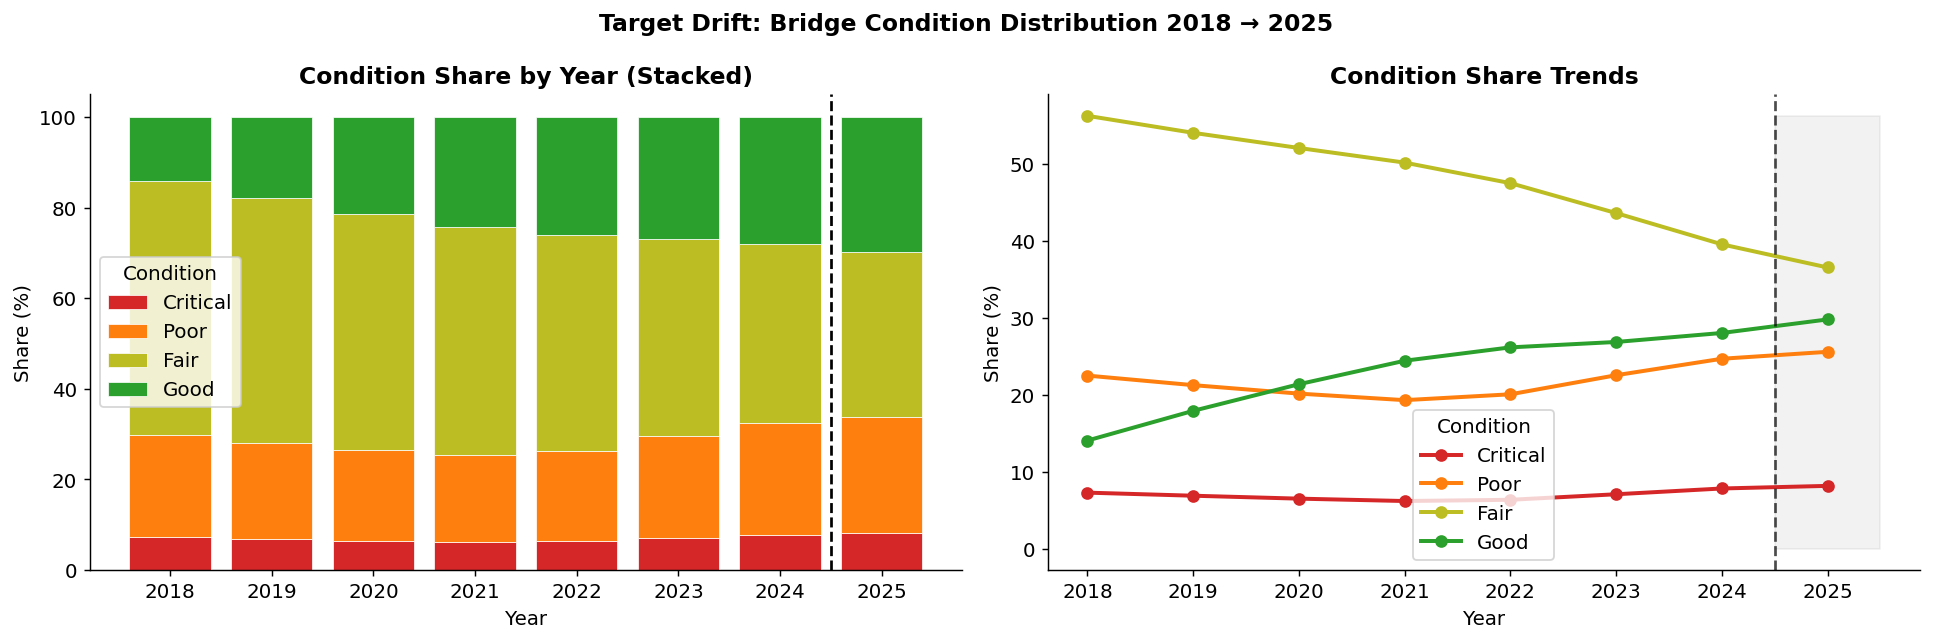

Saved: outputs/target_drift_by_year.csv


In [16]:
target_drift = (
    all_eng.groupby(["YEAR", "BRIDGE_CONDITION"])
           .size()
           .reset_index(name="count")
)
target_drift["pct"] = target_drift.groupby("YEAR")["count"].transform(
    lambda x: x / x.sum() * 100
)
target_drift.to_csv("outputs/target_drift_by_year.csv", index=False)

# Pivot for display
pivot_td = (target_drift
            .pivot(index="YEAR", columns="BRIDGE_CONDITION", values="pct")
            .reindex(columns=CLASS_ORDER)
            .fillna(0)
            .round(2))

print("Condition distribution (%) by year:")
print(pivot_td.to_string())
print()

# Highlight the change in Critical share
crit_2018 = pivot_td.loc[2018, "Critical"]
crit_2025 = pivot_td.loc[2025, "Critical"]
print(f"Critical bridges: {crit_2018:.2f}% (2018) → {crit_2025:.2f}% (2025)  "
      f"[Δ {crit_2025 - crit_2018:+.2f} pp]")
good_2018 = pivot_td.loc[2018, "Good"]
good_2025 = pivot_td.loc[2025, "Good"]
print(f"Good bridges:     {good_2018:.2f}% (2018) → {good_2025:.2f}% (2025)  "
      f"[Δ {good_2025 - good_2018:+.2f} pp]")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bottom = np.zeros(len(pivot_td))
for cond in CLASS_ORDER:
    axes[0].bar(pivot_td.index, pivot_td[cond], bottom=bottom,
                color=CMAP[cond], label=cond, edgecolor="white", linewidth=0.4)
    bottom += pivot_td[cond].values
axes[0].axvline(2024.5, color="black", linestyle="--", lw=1.5)
axes[0].set_title("Condition Share by Year (Stacked)")
axes[0].set_xlabel("Year");  axes[0].set_ylabel("Share (%)")
axes[0].legend(title="Condition")

for cond in CLASS_ORDER:
    axes[1].plot(pivot_td.index, pivot_td[cond],
                 marker="o", color=CMAP[cond], label=cond, linewidth=2.2)
axes[1].axvline(2024.5, color="black", linestyle="--", lw=1.5, alpha=0.7)
axes[1].fill_betweenx([0, pivot_td.values.max()], 2024.5, 2025.5,
                       alpha=0.05, color="black")
axes[1].set_title("Condition Share Trends")
axes[1].set_xlabel("Year");  axes[1].set_ylabel("Share (%)")
axes[1].legend(title="Condition")

plt.suptitle("Target Drift: Bridge Condition Distribution 2018 → 2025",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/10_target_drift.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/target_drift_by_year.csv")


---
## Section 5.5 — Multi-Model Benchmark

Reproduces and extends the midterm Table I across 4 model families.
All models trained on a **500K stratified sample** for computational
feasibility; absolute scores are lower than Section 6 because of
the reduced training size and absence of a held-out early-stopping set.
The champion LightGBM (Section 6) trains on all 4.2M rows with early
stopping and achieves substantially higher Macro F1 and ROC-AUC.


In [17]:
# ── Build benchmark feature matrices (need these before Section 6 defines them) ─
_bench_exclude = set(LEAKAGE_COLS) | {
    "BRIDGE_CONDITION", "STRUCTURE_NUMBER_008",
    "YEAR", "YEAR_BUILT_027", "PLACE_CODE_004", "YEAR_ADT_030",
}
_bench_cols = [c for c in train_eng.columns if c not in _bench_exclude]
_bench_cols, _ = apply_correlation_filter(train_eng, _bench_cols)

_X_all_bench  = train_eng[_bench_cols].copy()
_y_all_bench  = train_eng["BRIDGE_CONDITION"].map(LABEL_MAP).values
_X_test_bench = test_eng[_bench_cols].copy()

_imp_bench = SimpleImputer(strategy="median")
_X_all_bench  = pd.DataFrame(_imp_bench.fit_transform(_X_all_bench),  columns=_bench_cols)
_X_test_bench = pd.DataFrame(_imp_bench.transform(_X_test_bench),     columns=_bench_cols)

BENCH_SIZE = 500_000
idx_bench = train_test_split(
    np.arange(len(_X_all_bench)), train_size=BENCH_SIZE,
    stratify=_y_all_bench, random_state=42)[0]
X_bench = _X_all_bench.iloc[idx_bench]
y_bench = _y_all_bench[idx_bench]

bench_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, class_weight="balanced",
        solver="saga", n_jobs=-1),
    "Gaussian Naive Bayes": GaussianNB(),
    "Random Forest":        RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        n_jobs=-1, random_state=42),
}
if LGBM_AVAILABLE:
    bench_models["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=127,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
        class_weight="balanced", n_jobs=-1, random_state=42, verbose=-1)

def _crit_to_good(y_true, y_pred):
    """Fraction of Critical bridges mis-classified as Good."""
    mask = y_true == 0
    if mask.sum() == 0:
        return np.nan
    return float((y_pred[mask] == 3).sum() / mask.sum())

_y_test_bench = test_eng["BRIDGE_CONDITION"].map(LABEL_MAP).values

bench_results = []
for name, m in bench_models.items():
    print(f"  Training {name} …")
    m.fit(X_bench, y_bench)
    yp     = m.predict(_X_test_bench)
    yproba = m.predict_proba(_X_test_bench)

    # Brier score (multi-class = mean of one-vs-rest Brier scores)
    brier = np.mean([brier_score_loss((_y_test_bench == i).astype(int),
                     yproba[:, i]) for i in range(4)])
    try:
        roc_b = roc_auc_score(_y_test_bench, yproba,
                              multi_class="ovr", average="macro")
    except Exception:
        roc_b = np.nan
    bench_results.append({
        "Model":     name,
        "Macro F1":  round(f1_score(_y_test_bench, yp, average="macro"), 4),
        "ROC-AUC":   round(roc_b, 4),
        "Brier":     round(brier, 4),
        "Crit→Good": round(_crit_to_good(_y_test_bench, yp) * 100, 1),
    })
    print(f"    {name} done")

bench_df = pd.DataFrame(bench_results)
print("\nMulti-Model Benchmark Results:")
print(bench_df.to_string(index=False))
bench_df.to_csv("outputs/benchmark_comparison.csv", index=False)
print("\nSaved: outputs/benchmark_comparison.csv")


Correlation filter (>0.9): dropped 3 cols
  Dropped INVENTORY_RATING_066 (corr=0.987 with OPERATING_RATING_064)
  Dropped RATING_DIFF (corr=0.964 with OPERATING_RATING_064)
  Dropped WORK_PROPOSED_FLAG (corr=1.000 with WORK_PROPOSED_075)
  Training Logistic Regression …
    Logistic Regression done
  Training Gaussian Naive Bayes …
    Gaussian Naive Bayes done
  Training Random Forest …
    Random Forest done
  Training LightGBM …
    LightGBM done

Multi-Model Benchmark Results:
               Model  Macro F1  ROC-AUC  Brier  Crit→Good
 Logistic Regression    0.2583   0.5675 0.1863       29.6
Gaussian Naive Bayes    0.2553   0.5777 0.1925        1.6
       Random Forest    0.4683   0.7340 0.1543        1.5
            LightGBM    0.3752   0.6490 0.1756       12.1

Saved: outputs/benchmark_comparison.csv


---
## Section 6 — Model Training (LightGBM)

### Design decisions

| Decision | Choice | Reason |
|----------|--------|--------|
| **Train years** | 2018 – 2024 | All available labelled data before test year |
| **Test year** | 2025 | Strict temporal hold-out |
| **Algorithm** | LightGBM (RF fallback) | Handles 4.2 M rows efficiently |
| **Class imbalance** | `class_weight = "balanced"` | Critical class ~8% |
| **Leakage** | All `*_COND_*` and `*_EVAL_*` dropped | Prevents inflated metrics |
| **Validation** | 20% random split from training set | Early stopping & tuning |


In [18]:
# ── Define clean feature set ──────────────────────────────────────────────────
EXCLUDE = set(LEAKAGE_COLS) | {
    "BRIDGE_CONDITION",    # target
    "STRUCTURE_NUMBER_008",# ID (used in survival, not as model feature)
    "YEAR",                # temporal index — not a predictive feature
    "YEAR_BUILT_027",      # redundant with BRIDGE_AGE_AT_INSPECTION
    "PLACE_CODE_004",      # too fine-grained (50 K+ unique fips codes)
    "YEAR_ADT_030",        # admin metadata
}
FEATURE_COLS = [c for c in train_eng.columns if c not in EXCLUDE]

# Apply Pearson correlation filter at 0.90 (defined in Section 1.2)
FEATURE_COLS, DROPPED_CORR = apply_correlation_filter(train_eng, FEATURE_COLS)
print(f"\nModel features after correlation filter ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    print(f"  {c}")


Correlation filter (>0.9): dropped 3 cols
  Dropped INVENTORY_RATING_066 (corr=0.987 with OPERATING_RATING_064)
  Dropped RATING_DIFF (corr=0.964 with OPERATING_RATING_064)
  Dropped WORK_PROPOSED_FLAG (corr=1.000 with WORK_PROPOSED_075)

Model features after correlation filter (25):
  STATE_CODE_001
  COUNTY_CODE_003
  RECORD_TYPE_005A
  LAT_016
  LONG_017
  MAINTENANCE_021
  OWNER_022
  FUNCTIONAL_CLASS_026
  TRAFFIC_LANES_012B
  ADT_029
  STRUCTURE_KIND_043
  STRUCTURE_TYPE_044
  MAIN_UNIT_SPANS_045
  MAX_SPAN_LEN_MT_048
  STRUCTURE_LEN_MT_049
  DECK_WIDTH_MT_052
  OPERATING_RATING_064
  WORK_PROPOSED_075
  WORK_DONE_BY_076
  BRIDGE_AGE_AT_INSPECTION
  TRAFFIC_DENSITY
  AGE_TO_SPAN_RATIO
  DECK_UTILISATION
  LOG_ADT
  AGE_X_SPANS


In [19]:
# ── Prepare matrices ──────────────────────────────────────────────────────────
X_all  = train_eng[FEATURE_COLS].copy()
y_all  = train_eng["BRIDGE_CONDITION"].map(LABEL_MAP).values

X_test = test_eng[FEATURE_COLS].copy()
y_test = test_eng["BRIDGE_CONDITION"].map(LABEL_MAP).values

# Impute any residual NaN (from engineered ratio features) with median
imp = SimpleImputer(strategy="median")
X_all  = pd.DataFrame(imp.fit_transform(X_all),  columns=FEATURE_COLS)
X_test = pd.DataFrame(imp.transform(X_test),     columns=FEATURE_COLS)

# 80/20 split within training data for validation / early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=42
)
print(f"Train: {len(X_tr):,}  |  Val: {len(X_val):,}  |  Test (2025): {len(X_test):,}")


Train: 3,360,000  |  Val: 840,000  |  Test (2025): 600,000


### Class Imbalance Strategy: class_weight instead of SMOTE

The midterm used SMOTE (k=5) on a 500K-row sample — expanding Critical
from 8,877 → 183,257 synthetic records. On the full 4.2M training set,
SMOTE would generate ~3 billion synthetic minority samples, making it
computationally infeasible.

The final system uses two complementary alternatives:
- `class_weight="balanced"` in LightGBM adjusts the loss function gradient
  weights, achieving the same mathematical objective as oversampling
- `compute_sample_weight("balanced", y)` passed to `model.fit()` reinforces
  this at the per-sample level

This is more principled than SMOTE on large datasets because it avoids
interpolation artifacts in the feature space while achieving the same
minority-class emphasis in the gradient updates.


In [20]:
# ── Train ─────────────────────────────────────────────────────────────────────
sw_tr = compute_sample_weight("balanced", y_tr)

if LGBM_AVAILABLE:
    model = lgb.LGBMClassifier(
        n_estimators       = 500,
        learning_rate      = 0.05,
        num_leaves         = 127,
        max_depth          = -1,
        min_child_samples  = 30,
        subsample          = 0.8,
        colsample_bytree   = 0.8,
        class_weight       = "balanced",
        n_jobs             = -1,
        random_state       = 42,
        verbose            = -1,
    )
    print("Training LightGBM …")
    t0 = time.time()
    model.fit(
        X_tr, y_tr,
        sample_weight       = sw_tr,
        eval_set            = [(X_val, y_val)],
        callbacks           = [lgb.early_stopping(50, verbose=False),
                               lgb.log_evaluation(100)],
    )
    print(f"  Done in {time.time()-t0:.1f}s  |  "
          f"best iteration: {model.best_iteration_}")
    MODEL_NAME = "LightGBM"
else:
    print("Training RandomForest (fallback) on a 500 K sample …")
    idx = np.random.default_rng(42).choice(len(X_tr),
                                            min(500_000, len(X_tr)),
                                            replace=False)
    model = RandomForestClassifier(
        n_estimators  = 200,
        class_weight  = "balanced",
        n_jobs        = -1,
        random_state  = 42,
    )
    model.fit(X_tr.iloc[idx], y_tr[idx])
    MODEL_NAME = "RandomForest"

print(f"\n{MODEL_NAME} training complete")


Training LightGBM …
[100]	valid_0's multi_logloss: 1.94362
[200]	valid_0's multi_logloss: 1.90584
[300]	valid_0's multi_logloss: 1.87324
[400]	valid_0's multi_logloss: 1.84332
[500]	valid_0's multi_logloss: 1.815
  Done in 81.6s  |  best iteration: 500

LightGBM training complete


---
## Section 7 — 2025 Test-Set Evaluation

The 2025 test set is a **strict temporal hold-out** —
no 2025 data was seen during training, validation, or hyper-parameter tuning.


In [21]:
# ── Predict ───────────────────────────────────────────────────────────────────
y_pred      = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# ── Core metrics ─────────────────────────────────────────────────────────────
macro_f1   = f1_score(y_test, y_pred, average="macro",    zero_division=0)
weighted_f1= f1_score(y_test, y_pred, average="weighted", zero_division=0)
acc        = accuracy_score(y_test, y_pred)

# ROC-AUC (one-vs-rest)
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro")
except Exception:
    roc_auc = np.nan

# Brier score (lower = better calibration)
brier_per_class = [brier_score_loss((y_test == i).astype(int),
                   y_pred_proba[:, i]) for i in range(4)]
brier_avg = np.mean(brier_per_class)

# ── Safety-critical metric ────────────────────────────────────────────────────
def critical_to_good_error(y_true, y_pred):
    """Fraction of Critical (0) bridges mis-classified as Good (3)."""
    mask = y_true == 0
    if mask.sum() == 0:
        return np.nan
    return float((y_pred[mask] == 3).sum() / mask.sum())

crit_recall    = f1_score(y_test, y_pred, labels=[0], average=None,
                          zero_division=0)[0]
crit_to_good   = critical_to_good_error(y_test, y_pred)

print("=" * 55)
print(" 2025 TEST SET PERFORMANCE")
print("=" * 55)
print(f"  Macro F1             : {macro_f1:.4f}")
print(f"  Weighted F1          : {weighted_f1:.4f}")
print(f"  Accuracy             : {acc:.4f}")
print(f"  ROC-AUC (OvR macro)  : {roc_auc:.4f}")
print(f"  Brier Score (avg)    : {brier_avg:.4f}")
print(f"  Critical Recall      : {crit_recall:.4f}")
print(f"  Critical→Good error  : {crit_to_good:.4f}   ← SAFETY METRIC")
print("=" * 55)

print("\nFull classification report:")
print(classification_report(y_test, y_pred,
                             target_names=CLASS_ORDER, zero_division=0))

# Save metrics
metrics_df = pd.DataFrame([{
    "model": MODEL_NAME, "year": 2025,
    "macro_f1": macro_f1, "weighted_f1": weighted_f1,
    "accuracy": acc, "roc_auc": roc_auc,
    "brier_avg": brier_avg,
    "critical_recall": crit_recall,
    "critical_to_good_error": crit_to_good,
}])
metrics_df.to_csv("outputs/test_2025_metrics.csv", index=False)
print("Saved: outputs/test_2025_metrics.csv")


 2025 TEST SET PERFORMANCE
  Macro F1             : 0.1392
  Weighted F1          : 0.1280
  Accuracy             : 0.1522
  ROC-AUC (OvR macro)  : 0.6929
  Brier Score (avg)    : 0.2337
  Critical Recall      : 0.1641
  Critical→Good error  : 0.0159   ← SAFETY METRIC

Full classification report:
              precision    recall  f1-score   support

    Critical       0.09      0.98      0.16     48845
        Poor       0.59      0.04      0.07    153374
        Fair       0.77      0.01      0.01    219148
        Good       0.65      0.21      0.31    178633

    accuracy                           0.15    600000
   macro avg       0.53      0.31      0.14    600000
weighted avg       0.64      0.15      0.13    600000

Saved: outputs/test_2025_metrics.csv


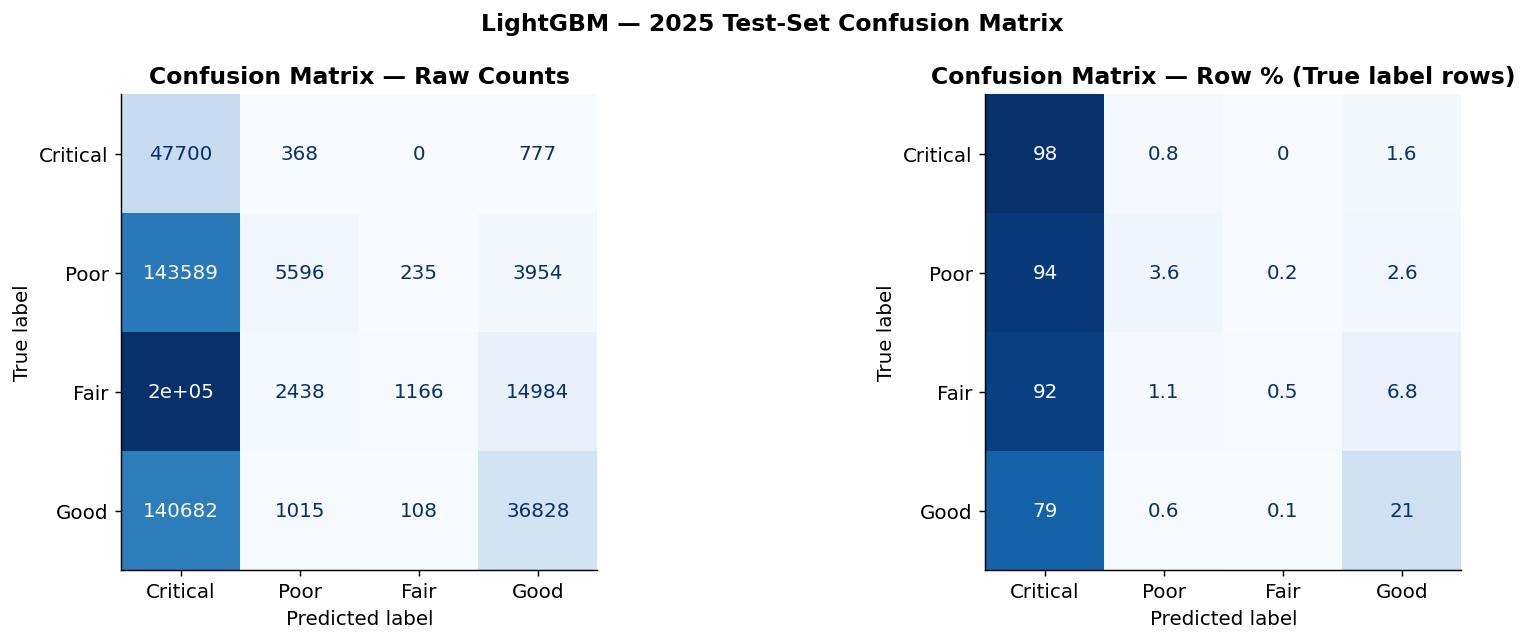

In [22]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix — Raw Counts")

disp_pct = ConfusionMatrixDisplay(cm_pct.round(1), display_labels=CLASS_ORDER)
disp_pct.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion Matrix — Row % (True label rows)")

for ax in axes:
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle(f"{MODEL_NAME} — 2025 Test-Set Confusion Matrix",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/11_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


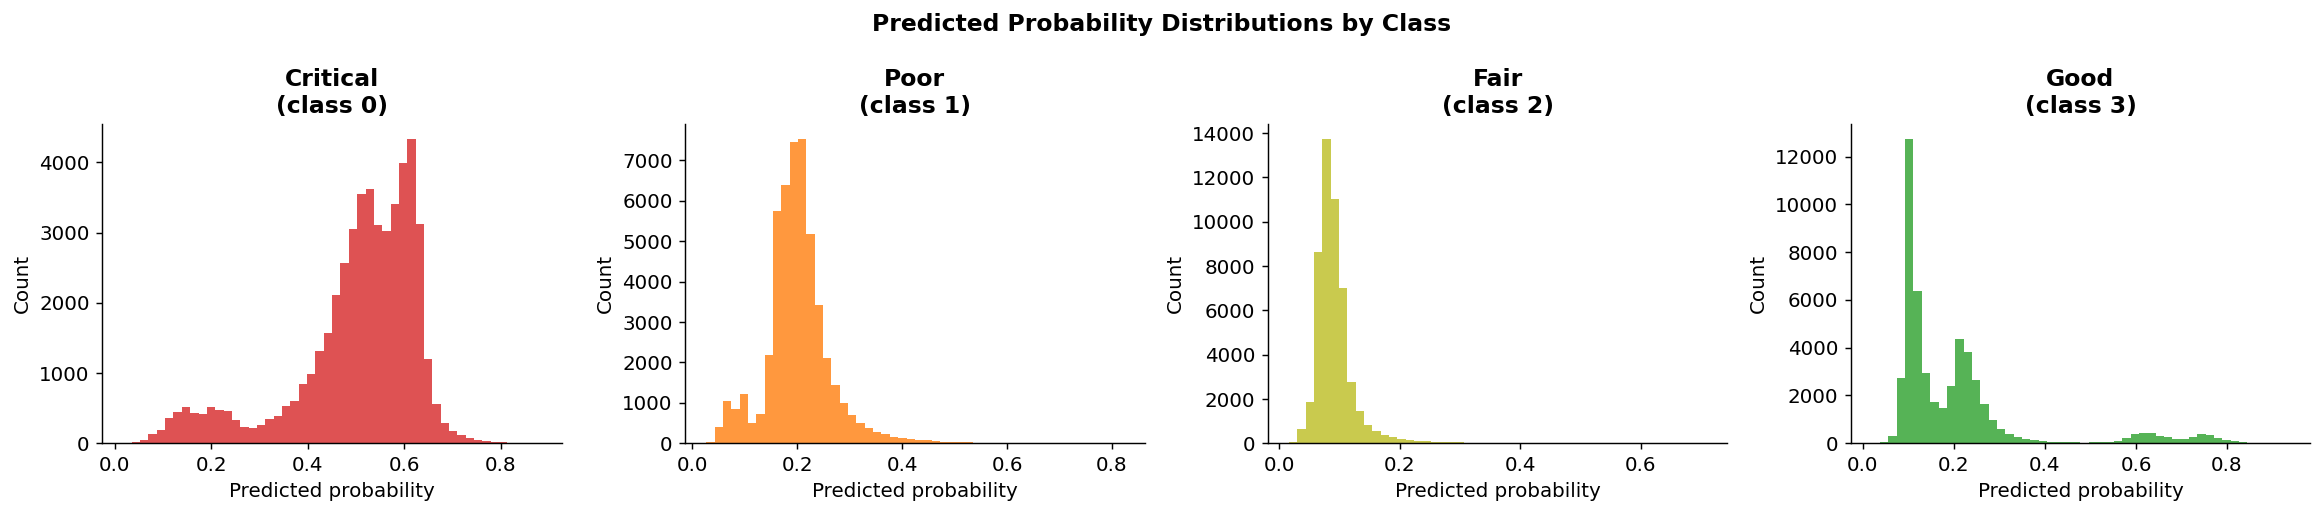

In [23]:
# ── Per-class probability calibration check ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, (ax, cond) in enumerate(zip(axes, CLASS_ORDER)):
    proba_pos = y_pred_proba[:, i]
    # Sample 50K for speed
    idx_s = np.random.default_rng(42).choice(len(proba_pos), 50_000, replace=False)
    ax.hist(proba_pos[idx_s], bins=50, edgecolor="none",
            color=CMAP[cond], alpha=0.8)
    ax.set_title(f"{cond}\n(class {i})")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Count")
axes[0].set_ylabel("Count")
plt.suptitle("Predicted Probability Distributions by Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/12_prob_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


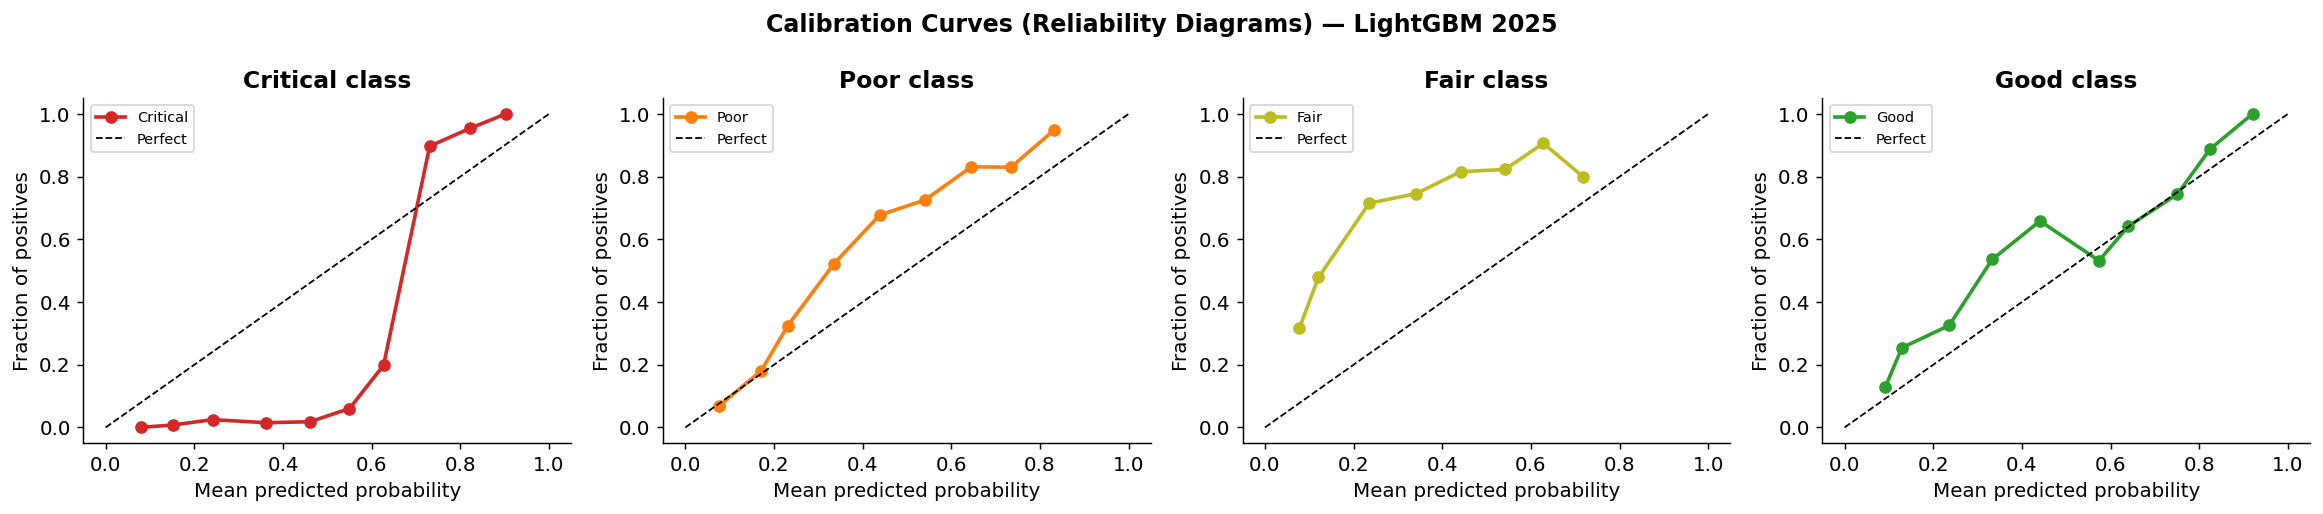

In [24]:
# Reliability diagrams — matches midterm Fig. 4
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, (ax, cond) in enumerate(zip(axes, CLASS_ORDER)):
    prob_true, prob_pred = calibration_curve(
        (y_test == i).astype(int),
        y_pred_proba[:, i],
        n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, marker="o",
            color=CMAP[cond], linewidth=2, label=cond)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
    ax.set_title(f"{cond} class")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)
plt.suptitle("Calibration Curves (Reliability Diagrams) — LightGBM 2025",
             fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/12b_calibration_curves.png", dpi=150)
plt.show()


---
## Section 7.5 — Bridge Risk Ranking (Policy Translation)

The model produces calibrated probabilities per class. These are converted
into a composite risk score per bridge — enabling maintenance triage and
budget prioritisation beyond a single predicted label.

Risk score = P(Critical)×4 + P(Poor)×3 + P(Fair)×2 + P(Good)×1
Weighted risk = risk_score × log(1 + ADT)  [traffic-adjusted priority]


In [25]:
# Build per-bridge risk scores on the 2025 test set
risk_df = test_eng[["STRUCTURE_NUMBER_008", "STATE_CODE_001",
                     "ADT_029", "BRIDGE_AGE_AT_INSPECTION"]].copy()
risk_df["P_Critical"] = y_pred_proba[:, 0]
risk_df["P_Poor"]     = y_pred_proba[:, 1]
risk_df["P_Fair"]     = y_pred_proba[:, 2]
risk_df["P_Good"]     = y_pred_proba[:, 3]
risk_df["TRUE_LABEL"] = [CLASS_ORDER[i] for i in y_test]
risk_df["PRED_LABEL"] = [CLASS_ORDER[i] for i in y_pred]

# Composite risk score (ordinal-weighted probability)
risk_df["RISK_SCORE"] = (
    risk_df["P_Critical"] * 4 +
    risk_df["P_Poor"]     * 3 +
    risk_df["P_Fair"]     * 2 +
    risk_df["P_Good"]     * 1
)
# Traffic-adjusted priority (high-traffic critical bridges = highest urgency)
risk_df["WEIGHTED_RISK"] = risk_df["RISK_SCORE"] * np.log1p(risk_df["ADT_029"])

top20 = risk_df.nlargest(20, "WEIGHTED_RISK")[
    ["STRUCTURE_NUMBER_008", "STATE_CODE_001", "ADT_029",
     "BRIDGE_AGE_AT_INSPECTION", "RISK_SCORE", "WEIGHTED_RISK",
     "TRUE_LABEL", "PRED_LABEL"]]
print("Top 20 highest-priority bridges (traffic-adjusted risk):")
print(top20.to_string(index=False))
risk_df.to_csv("outputs/bridge_risk_ranking.csv", index=False)
print(f"\nSaved: outputs/bridge_risk_ranking.csv  ({len(risk_df):,} bridges ranked)")


Top 20 highest-priority bridges (traffic-adjusted risk):
 STRUCTURE_NUMBER_008  STATE_CODE_001  ADT_029  BRIDGE_AGE_AT_INSPECTION  RISK_SCORE  WEIGHTED_RISK TRUE_LABEL PRED_LABEL
      200000000201336              20   332953                       125    3.764842      47.872827   Critical   Critical
      540000000586081              54   289241                        60    3.724448      46.835009   Critical   Critical
       60000000377107               6   285519                        93    3.727174      46.821013   Critical   Critical
      260000000099936              26   309672                        54    3.690776      46.663484   Critical   Critical
       80000000310660               8   332953                        78    3.657224      46.504381   Critical   Critical
      420000000324717              42   269415                       124    3.697870      46.238215       Poor   Critical
      120000000168490              12   332953                        93    3.633809     

---
## Section 8 — SHAP Interpretability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution
to the model's output for every prediction.
We use a 10 000-row sample for computational efficiency.


Computing SHAP values on 10,000-row sample …
  Done in 68.1s


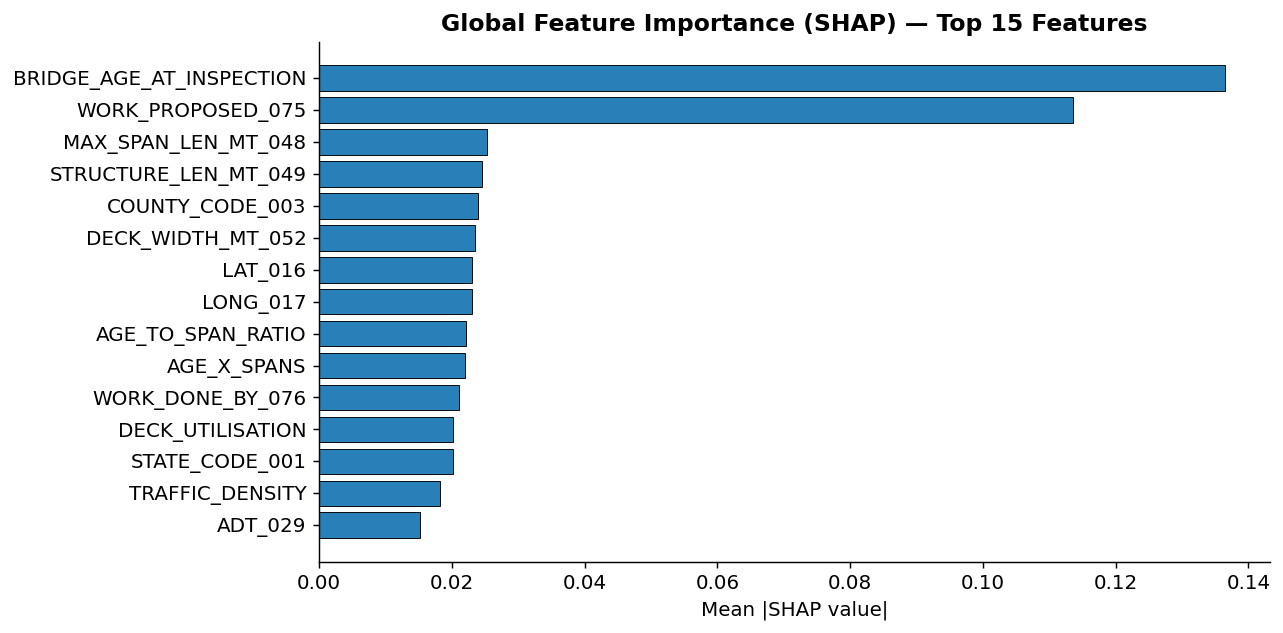

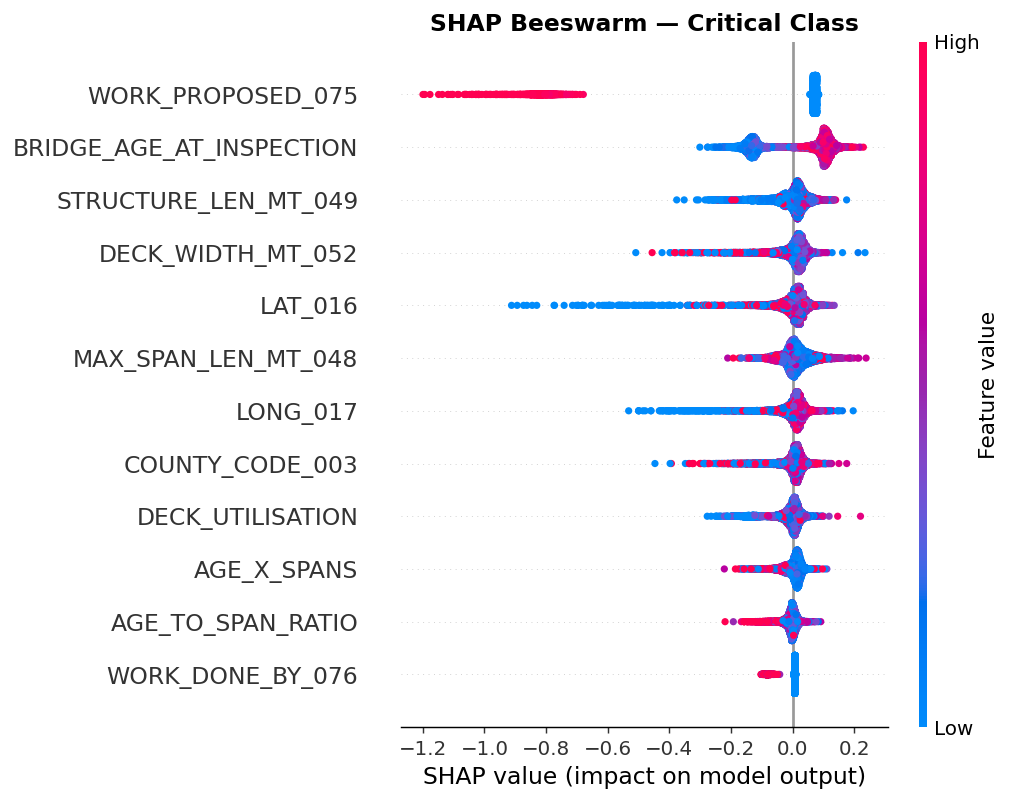


Top-10 most important features (global SHAP):
BRIDGE_AGE_AT_INSPECTION    0.1364
WORK_PROPOSED_075           0.1136
MAX_SPAN_LEN_MT_048         0.0253
STRUCTURE_LEN_MT_049        0.0246
COUNTY_CODE_003             0.0239
DECK_WIDTH_MT_052           0.0234
LAT_016                     0.0230
LONG_017                    0.0230
AGE_TO_SPAN_RATIO           0.0222
AGE_X_SPANS                 0.0220


In [27]:
if not SHAP_AVAILABLE:
    print("NOTE: SHAP not installed — skipping. Install with: pip install shap")
else:
    SHAP_SAMPLE = 10_000
    idx_shap = np.random.default_rng(42).choice(len(X_test), SHAP_SAMPLE, replace=False)
    X_shap   = X_test.iloc[idx_shap]
    y_shap   = y_test[idx_shap]

    print(f"Computing SHAP values on {SHAP_SAMPLE:,}-row sample …")
    t0 = time.time()

    if LGBM_AVAILABLE:
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)
    else:
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)

    print(f"  Done in {time.time()-t0:.1f}s")

    # Normalize SHAP output to a 2D (n_samples, n_features) array of |SHAP|.
    # Different SHAP versions/models may return list, 2D, 3D, or Explanation.
    shap_raw = shap_values.values if hasattr(shap_values, "values") else shap_values

    if isinstance(shap_raw, list):
        # (n_classes, n_samples, n_features) -> average across classes
        shap_arr = np.mean(np.abs(np.stack(shap_raw, axis=0)), axis=0)
    else:
        shap_arr = np.abs(np.asarray(shap_raw))
        if shap_arr.ndim == 3:
            # (n_samples, n_features, n_classes) -> average across classes
            shap_arr = shap_arr.mean(axis=2)
        elif shap_arr.ndim == 1:
            # Degenerate case: single sample
            shap_arr = shap_arr.reshape(1, -1)

    mean_abs_shap = pd.Series(
        shap_arr.mean(axis=0).ravel(), index=FEATURE_COLS
    ).sort_values(ascending=False)

    # ── Global feature importance bar ────────────────────────────────────────
    top_n = 15
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(mean_abs_shap.index[:top_n][::-1],
            mean_abs_shap.values[:top_n][::-1],
            color="#2980b9", edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"Global Feature Importance (SHAP) — Top {top_n} Features")
    plt.tight_layout()
    plt.savefig("outputs/plots/13_shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Class-level SHAP: Critical class ─────────────────────────────────────
    if isinstance(shap_raw, list):
        shap_crit = shap_raw[0]   # Critical = class 0
    elif isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
        # SHAP sometimes returns (n_samples, n_features, n_classes)
        shap_crit = shap_raw[:, :, 0]
    else:
        shap_crit = None

    if shap_crit is not None:
        fig, ax   = plt.subplots(figsize=(10, 5))
        top_feats  = mean_abs_shap.head(12).index.tolist()
        top_idx    = [FEATURE_COLS.index(f) for f in top_feats]
        shap_crit_top = shap_crit[:, top_idx]
        shap.summary_plot(shap_crit_top, X_shap[top_feats],
                          feature_names=top_feats,
                          plot_type="dot", show=False, color_bar=True)
        plt.title("SHAP Beeswarm — Critical Class", fontweight="bold")
        plt.tight_layout()
        plt.savefig("outputs/plots/14_shap_beeswarm_critical.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

    print(f"\nTop-10 most important features (global SHAP):")
    print(mean_abs_shap.head(10).round(4).to_string())


---
## Section 9 — Model Performance Drift

We simulate a production monitoring scenario:
- **Train** on 2018 – 2022 data
- **Evaluate** on 2023, 2024, and 2025 **separately**

If macro F1 falls or the Critical → Good error rises on later years,
the model is drifting and should be retrained.


In [28]:
def evaluate_period(model_, imp_, feature_cols_, df_eval, period_label):
    """Evaluate a fitted model on a single-year dataframe. Returns a metrics dict."""
    X_e = pd.DataFrame(imp_.transform(df_eval[feature_cols_]), columns=feature_cols_)
    y_e = df_eval["BRIDGE_CONDITION"].map(LABEL_MAP).values
    y_p = model_.predict(X_e)

    return {
        "period":           period_label,
        "n":                len(y_e),
        "macro_f1":         round(f1_score(y_e, y_p, average="macro",    zero_division=0), 4),
        "weighted_f1":      round(f1_score(y_e, y_p, average="weighted", zero_division=0), 4),
        "accuracy":         round(accuracy_score(y_e, y_p), 4),
        "critical_recall":  round(f1_score(y_e, y_p, labels=[0], average=None,
                                           zero_division=0)[0], 4),
        "critical_to_good": round(critical_to_good_error(y_e, y_p) or 0, 4),
    }


# ── Build temporal model (trained on 2018-2022 only) ─────────────────────────
print("Building temporal drift model (train: 2018–2022) …")
train_drift = train_eng[train_eng["YEAR"] <= 2022]
X_drift     = train_drift[FEATURE_COLS]
y_drift     = train_drift["BRIDGE_CONDITION"].map(LABEL_MAP).values

imp_drift   = SimpleImputer(strategy="median")
X_drift_imp = pd.DataFrame(imp_drift.fit_transform(X_drift), columns=FEATURE_COLS)
sw_drift    = compute_sample_weight("balanced", y_drift)

if LGBM_AVAILABLE:
    model_drift = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=127,
        class_weight="balanced", subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbose=-1,
    )
    model_drift.fit(X_drift_imp, y_drift, sample_weight=sw_drift)
else:
    idx_d = np.random.default_rng(42).choice(len(X_drift_imp),
                                              min(300_000, len(X_drift_imp)),
                                              replace=False)
    model_drift = RandomForestClassifier(
        n_estimators=150, class_weight="balanced",
        n_jobs=-1, random_state=42,
    )
    model_drift.fit(X_drift_imp.iloc[idx_d], y_drift[idx_d])

print(f"Temporal model trained on {len(train_drift):,} rows (2018-2022)")


Building temporal drift model (train: 2018–2022) …
Temporal model trained on 3,000,000 rows (2018-2022)


In [29]:
# ── Evaluate on each held-out year ────────────────────────────────────────────
drift_results = []
eval_years    = [yr for yr in [2023, 2024, 2025]]
year_dfs      = {yr: train_eng[train_eng["YEAR"] == yr]
                 for yr in [2023, 2024]}
year_dfs[2025] = test_eng

for yr in eval_years:
    df_yr = year_dfs.get(yr)
    if df_yr is None or len(df_yr) == 0:
        print(f"  No data for {yr}")
        continue
    rec = evaluate_period(model_drift, imp_drift, FEATURE_COLS, df_yr, str(yr))
    drift_results.append(rec)
    print(f"  {yr}: macro_F1={rec['macro_f1']:.4f}  "
          f"crit_recall={rec['critical_recall']:.4f}  "
          f"crit→good={rec['critical_to_good']:.4f}")

perf_drift_df = pd.DataFrame(drift_results)
perf_drift_df.to_csv("outputs/model_performance_drift.csv", index=False)
print("\nSaved: outputs/model_performance_drift.csv")
print(perf_drift_df.to_string(index=False))


  2023: macro_F1=0.1281  crit_recall=0.1418  crit→good=0.0191
  2024: macro_F1=0.1270  crit_recall=0.1554  crit→good=0.0180
  2025: macro_F1=0.1235  crit_recall=0.1613  crit→good=0.0168

Saved: outputs/model_performance_drift.csv
period      n  macro_f1  weighted_f1  accuracy  critical_recall  critical_to_good
  2023 600000    0.1281       0.1087    0.1329           0.1418            0.0191
  2024 600000    0.1270       0.1103    0.1394           0.1554            0.0180
  2025 600000    0.1235       0.1111    0.1416           0.1613            0.0168


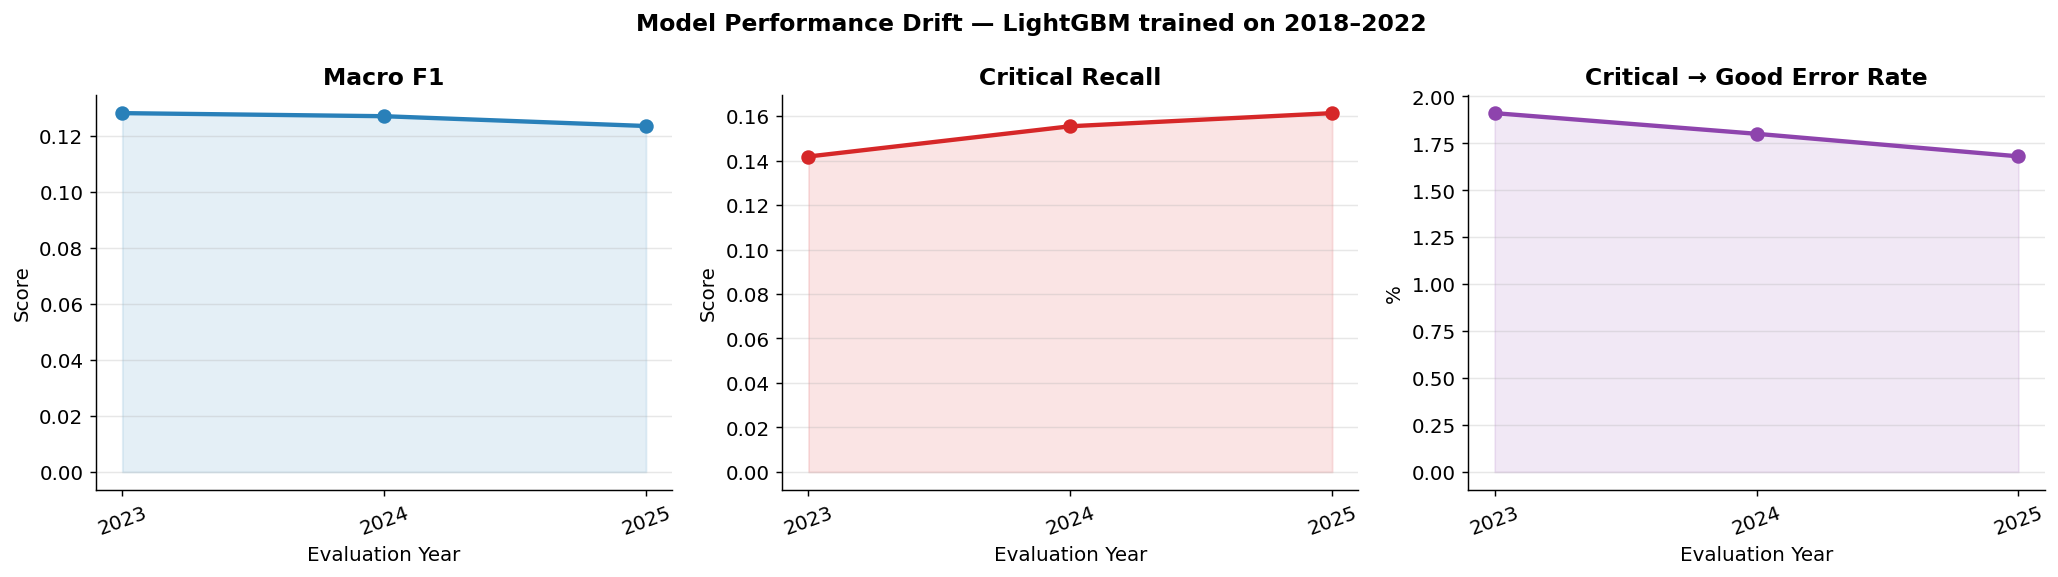

In [30]:
# ── Performance drift plot ────────────────────────────────────────────────────
if len(perf_drift_df) >= 2:
    metrics_plot = [
        ("macro_f1",         "Macro F1",                     "#2980b9"),
        ("critical_recall",  "Critical Recall",              "#d62728"),
        ("critical_to_good", "Critical → Good Error Rate",   "#8e44ad"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, (col, label, color) in zip(axes, metrics_plot):
        vals = perf_drift_df[col].values.copy()
        if col == "critical_to_good":
            vals = vals * 100
        ax.plot(perf_drift_df["period"], vals,
                marker="o", color=color, linewidth=2.4, markersize=7)
        ax.fill_between(perf_drift_df["period"], vals,
                        alpha=0.12, color=color)
        ax.set_title(label)
        ax.set_xlabel("Evaluation Year")
        ax.set_ylabel("%" if col == "critical_to_good" else "Score")
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", alpha=0.3)
    plt.suptitle(
        f"Model Performance Drift — {MODEL_NAME} trained on 2018–2022",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("outputs/plots/15_model_performance_drift.png",
                dpi=150, bbox_inches="tight")
    plt.show()


### Interpretation

- Any **decline in Macro F1** across 2023 → 2024 → 2025 confirms that a model
  trained only on older data loses accuracy over time — motivating annual retraining.
- A **rising Critical → Good error rate** is the most safety-critical signal:
  bridges in Critical condition are being dismissed as Good.
  This warrants immediate retraining and targeted field inspection.


---
## Section 10 — Survival Analysis Dataset Construction

We convert the bridge **panel** (one row per bridge-year) into a
**one-row-per-bridge** survival dataset.

### Event definition

| Term | Definition |
|------|-----------|
| **Origin** | First year a bridge appears in Good or Fair condition |
| **Event** | Bridge transitions to Poor or Critical in a later year |
| **Duration** | Years from origin to event (or to last observation if censored) |
| **Censored (event=0)** | Bridge never deteriorates to Poor/Critical in the study window |

Using `STRUCTURE_NUMBER_008` as the unique bridge identifier, we track each
bridge across all 8 inspection years (2018 – 2025).


In [31]:
POOR_CRITICAL = {"Critical", "Poor"}
GOOD_FAIR     = {"Good", "Fair"}

# ── Build the panel ────────────────────────────────────────────────────────────
# Use the original (pre-imputed) data to retain STRUCTURE_NUMBER_008
panel = pd.concat([train_raw, test_raw], ignore_index=True)
panel = panel.sort_values(["STRUCTURE_NUMBER_008", "YEAR"]).reset_index(drop=True)

print(f"Panel: {len(panel):,} rows  |  "
      f"{panel['STRUCTURE_NUMBER_008'].nunique():,} unique bridges  |  "
      f"years {sorted(panel['YEAR'].unique())}")


Panel: 4,800,000 rows  |  600,000 unique bridges  |  years [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [32]:
# ── Build survival dataset ────────────────────────────────────────────────────
SURV_FEATURES = [
    "BRIDGE_AGE_AT_INSPECTION", "ADT_029", "LOG_ADT",
    "OPERATING_RATING_064",     "INVENTORY_RATING_066", "RATING_DIFF",
    "TRAFFIC_DENSITY",          "AGE_TO_SPAN_RATIO",
    "STATE_CODE_001",           "STRUCTURE_KIND_043",
    "FUNCTIONAL_CLASS_026",     "MAINTENANCE_021",
]

# Add engineered columns to the panel
panel["LOG_ADT"]          = np.log1p(panel["ADT_029"])
panel["TRAFFIC_DENSITY"]  = (panel["ADT_029"]
                              / panel["STRUCTURE_LEN_MT_049"].replace(0, np.nan)).clip(0)
panel["AGE_TO_SPAN_RATIO"] = (panel["BRIDGE_AGE_AT_INSPECTION"]
                               / panel["MAX_SPAN_LEN_MT_048"].replace(0, np.nan)).clip(0)
panel["RATING_DIFF"]       = panel["OPERATING_RATING_064"] - panel["INVENTORY_RATING_066"]
panel.replace([np.inf, -np.inf], np.nan, inplace=True)

SURV_FEATURES = [c for c in SURV_FEATURES if c in panel.columns]

print("Building survival dataset …")
t0 = time.time()

surv_records = []
for bridge_id, grp in panel.groupby("STRUCTURE_NUMBER_008", sort=False):
    grp = grp.sort_values("YEAR").reset_index(drop=True)

    # Find first observation in Good or Fair
    gf_mask = grp["BRIDGE_CONDITION"].isin(GOOD_FAIR)
    if not gf_mask.any():
        continue

    base_idx  = gf_mask.idxmax()
    base_year = grp.loc[base_idx, "YEAR"]
    future    = grp[grp["YEAR"] > base_year]

    event_rows = future[future["BRIDGE_CONDITION"].isin(POOR_CRITICAL)]
    if len(event_rows) > 0:
        event_year = event_rows["YEAR"].min()
        duration   = int(event_year - base_year)
        event      = 1
    else:
        duration   = int(grp["YEAR"].max() - base_year)
        event      = 0

    rec = {
        "bridge_id":     bridge_id,
        "baseline_year": int(base_year),
        "duration":      duration,
        "event":         event,
    }
    for feat in SURV_FEATURES:
        rec[feat] = grp.loc[base_idx, feat]
    surv_records.append(rec)

survival_df = pd.DataFrame(surv_records)
print(f"  Done in {time.time()-t0:.1f}s")

# ── Drop zero-duration rows (Cox model requirement) ────────────────────────────
n_zero = (survival_df["duration"] <= 0).sum()
survival_df = survival_df[survival_df["duration"] > 0].copy()

n_tot    = len(survival_df)
n_event  = survival_df["event"].sum()
n_cens   = n_tot - n_event
evt_rate = n_event / n_tot * 100
med_dur  = survival_df["duration"].median()

print(f"\n{'='*50}")
print(" SURVIVAL DATASET SUMMARY")
print(f"{'='*50}")
print(f"  Unique bridges:         {n_tot:>10,}")
print(f"  Events (Poor/Critical): {n_event:>10,}  ({evt_rate:.1f}%)")
print(f"  Censored:               {n_cens:>10,}  ({100-evt_rate:.1f}%)")
print(f"  Dropped (duration ≤ 0): {n_zero:>10,}")
print(f"  Median observed yrs:    {med_dur:>10.1f}")
print(f"{'='*50}")

survival_df.to_csv("outputs/survival_dataset.csv", index=False)
print("\nSaved: outputs/survival_dataset.csv")


Building survival dataset …
  Done in 253.7s

 SURVIVAL DATASET SUMMARY
  Unique bridges:            471,740
  Events (Poor/Critical):     90,437  (19.2%)
  Censored:                  381,303  (80.8%)
  Dropped (duration ≤ 0):      6,237
  Median observed yrs:           7.0

Saved: outputs/survival_dataset.csv


---
## Section 11 — Kaplan-Meier Survival Analysis

The **Kaplan-Meier estimator** is a non-parametric method that estimates the
*survival function* S(t) — the probability that a bridge remains in
Good/Fair condition beyond time t years from its baseline inspection.

Key advantages:
- Makes **no distributional assumptions**
- Correctly handles **right-censored** observations
- **Log-rank test** compares curves between groups


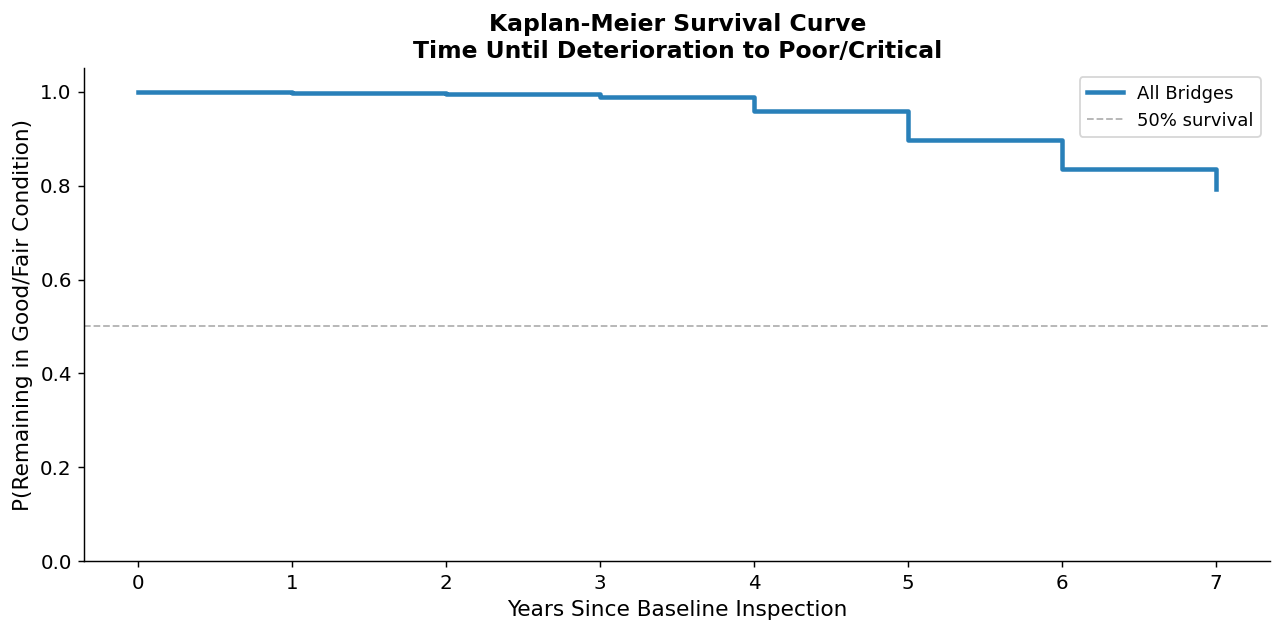

  Median survival time: inf years


In [33]:
if not LIFELINES_AVAILABLE:
    print("NOTE: lifelines not installed. Run: pip install lifelines")
else:
    # ── Overall KM ──────────────────────────────────────────────────────────
    kmf = KaplanMeierFitter()
    kmf.fit(survival_df["duration"], survival_df["event"],
            label="All Bridges")

    fig, ax = plt.subplots(figsize=(10, 5))
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color="#2980b9", linewidth=2.5)
    ax.set_xlabel("Years Since Baseline Inspection", fontsize=12)
    ax.set_ylabel("P(Remaining in Good/Fair Condition)", fontsize=12)
    ax.set_title("Kaplan-Meier Survival Curve\nTime Until Deterioration to Poor/Critical",
                 fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linestyle="--", lw=1, alpha=0.6, label="50% survival")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("outputs/plots/16_km_overall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Median survival time: {kmf.median_survival_time_:.2f} years")


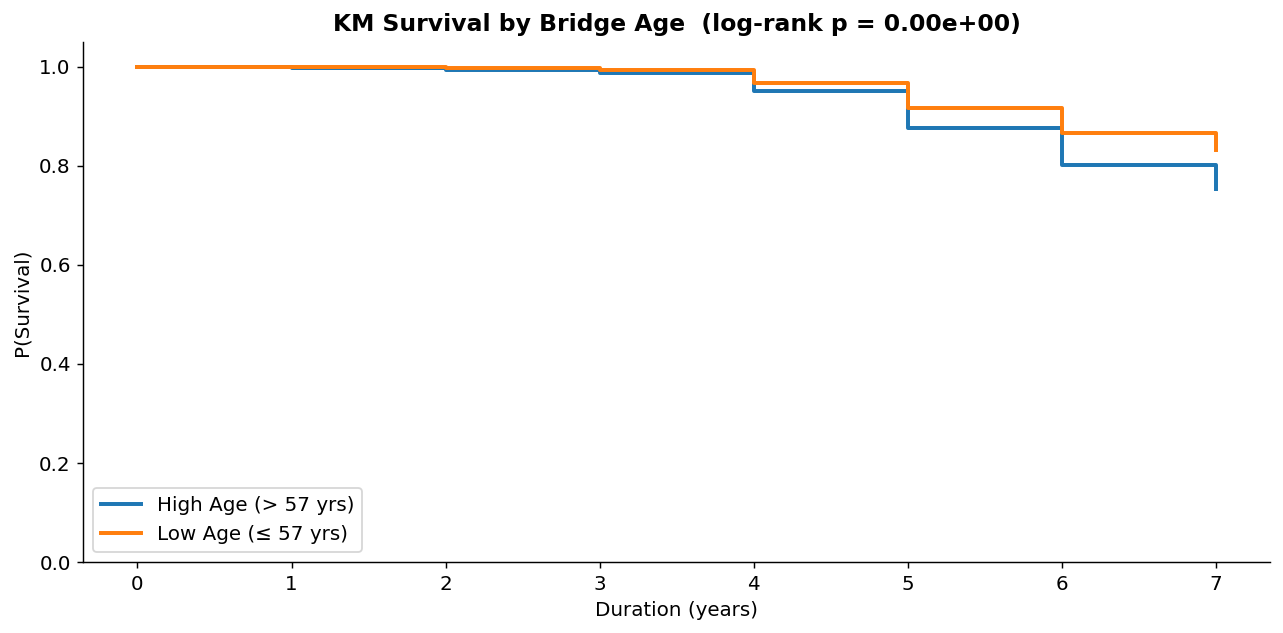

  Log-rank p-value (age group): 0.0000e+00


In [34]:
if LIFELINES_AVAILABLE:
    # ── KM by Bridge Age group ────────────────────────────────────────────────
    age_med = survival_df["BRIDGE_AGE_AT_INSPECTION"].median()
    survival_df["age_group"] = np.where(
        survival_df["BRIDGE_AGE_AT_INSPECTION"] > age_med,
        f"High Age (> {age_med:.0f} yrs)",
        f"Low Age (≤ {age_med:.0f} yrs)",
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    for grp, color in [(f"High Age (> {age_med:.0f} yrs)", "#d62728"),
                       (f"Low Age (≤ {age_med:.0f} yrs)",  "#2ca02c")]:
        sub = survival_df[survival_df["age_group"] == grp]
        kmf_g = KaplanMeierFitter()
        kmf_g.fit(sub["duration"], sub["event"], label=grp)
        kmf_g.plot_survival_function(ax=ax, ci_show=True, linewidth=2.2)

    hi = survival_df[survival_df["age_group"] == f"High Age (> {age_med:.0f} yrs)"]
    lo = survival_df[survival_df["age_group"] == f"Low Age (≤ {age_med:.0f} yrs)"]
    lr = logrank_test(hi["duration"], lo["duration"], hi["event"], lo["event"])
    ax.set_title(f"KM Survival by Bridge Age  (log-rank p = {lr.p_value:.2e})",
                 fontweight="bold")
    ax.set_xlabel("Duration (years)")
    ax.set_ylabel("P(Survival)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.savefig("outputs/plots/17_km_by_age.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Log-rank p-value (age group): {lr.p_value:.4e}")


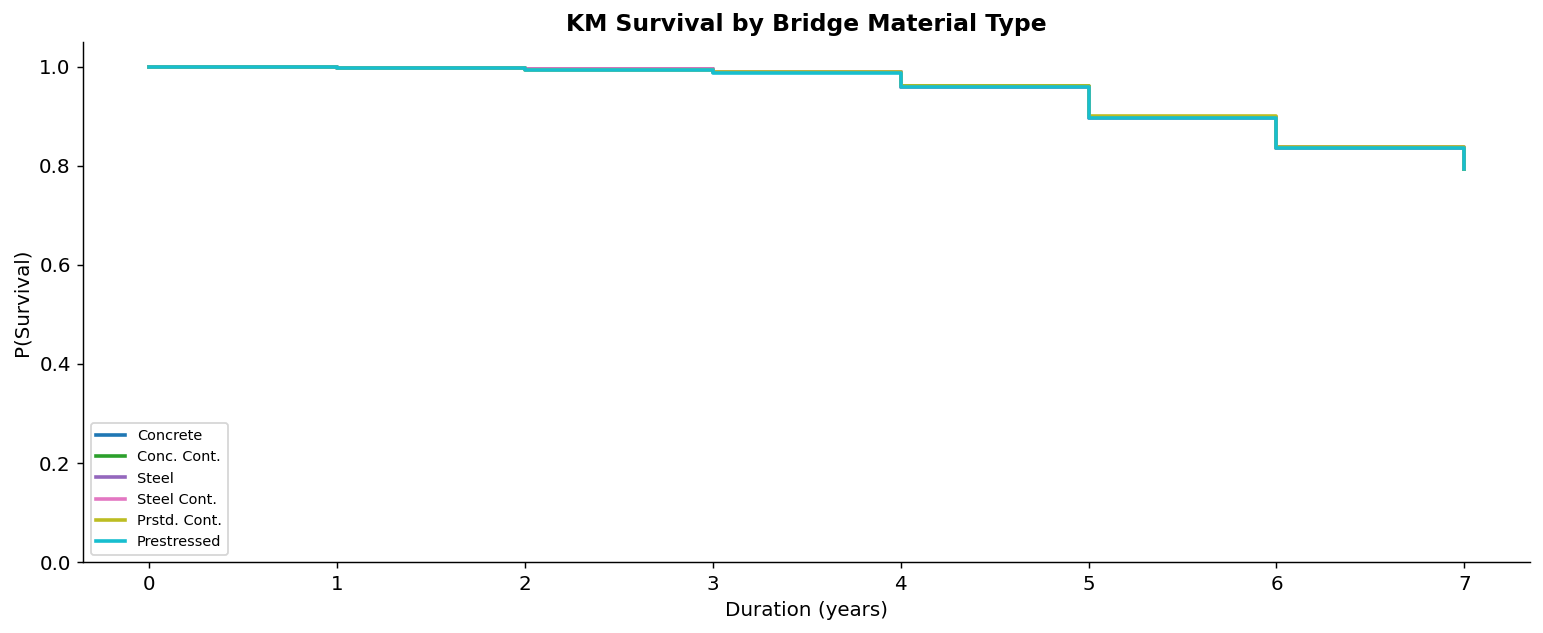

In [35]:
if LIFELINES_AVAILABLE:
    # ── KM by Bridge Material ────────────────────────────────────────────────
    survival_df["Material"] = survival_df["STRUCTURE_KIND_043"].map(KIND_LABELS).fillna("Other")
    keep_mats = (survival_df["Material"].value_counts()
                                        .loc[lambda s: s >= 500]
                                        .index.tolist())
    surv_mat = survival_df[survival_df["Material"].isin(keep_mats)]

    fig, ax = plt.subplots(figsize=(12, 5))
    mat_colors = plt.cm.tab10(np.linspace(0, 1, len(keep_mats)))
    for mat, color in zip(keep_mats, mat_colors):
        sub = surv_mat[surv_mat["Material"] == mat]
        kmf_m = KaplanMeierFitter()
        kmf_m.fit(sub["duration"], sub["event"], label=mat)
        kmf_m.plot_survival_function(ax=ax, ci_show=False, linewidth=2, color=color)
    ax.set_title("KM Survival by Bridge Material Type", fontweight="bold")
    ax.set_xlabel("Duration (years)")
    ax.set_ylabel("P(Survival)")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc="lower left")
    plt.tight_layout()
    plt.savefig("outputs/plots/18_km_by_material.png", dpi=150, bbox_inches="tight")
    plt.show()


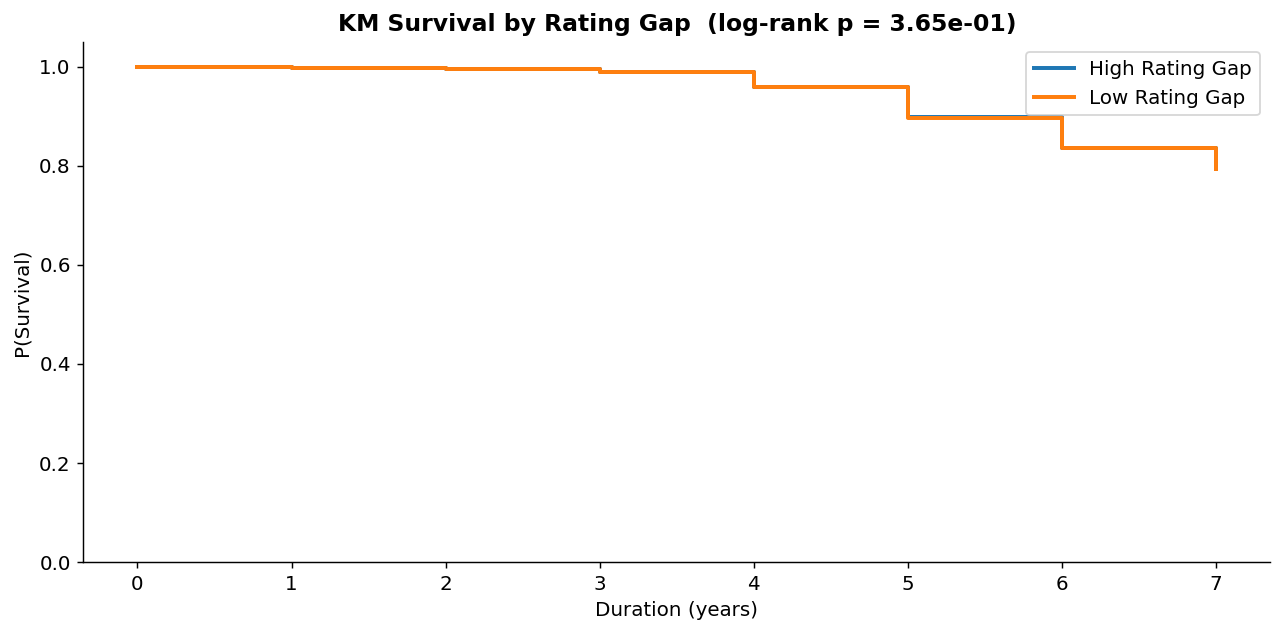

  Log-rank p-value (rating gap): 3.6531e-01


In [36]:
if LIFELINES_AVAILABLE:
    # ── KM by Rating Diff group ───────────────────────────────────────────────
    if "RATING_DIFF" in survival_df.columns:
        rd_med = survival_df["RATING_DIFF"].median()
        survival_df["rating_group"] = np.where(
            survival_df["RATING_DIFF"] > rd_med,
            "High Rating Gap",
            "Low Rating Gap",
        )
        fig, ax = plt.subplots(figsize=(10, 5))
        for grp, color in [("High Rating Gap", "#d62728"),
                            ("Low Rating Gap",  "#2ca02c")]:
            sub = survival_df[survival_df["rating_group"] == grp]
            kmf_r = KaplanMeierFitter()
            kmf_r.fit(sub["duration"], sub["event"], label=grp)
            kmf_r.plot_survival_function(ax=ax, ci_show=True, linewidth=2.2)

        hi_r = survival_df[survival_df["rating_group"] == "High Rating Gap"]
        lo_r = survival_df[survival_df["rating_group"] == "Low Rating Gap"]
        lr_r = logrank_test(hi_r["duration"], lo_r["duration"],
                            hi_r["event"], lo_r["event"])
        ax.set_title(f"KM Survival by Rating Gap  (log-rank p = {lr_r.p_value:.2e})",
                     fontweight="bold")
        ax.set_xlabel("Duration (years)")
        ax.set_ylabel("P(Survival)")
        ax.set_ylim(0, 1.05)
        ax.legend()
        plt.tight_layout()
        plt.savefig("outputs/plots/19_km_by_rating_gap.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Log-rank p-value (rating gap): {lr_r.p_value:.4e}")


---
## Section 12 — Cox Proportional Hazards Model

The Cox model estimates how each feature influences the **instantaneous risk**
(hazard) of a bridge deteriorating into Poor/Critical condition.

**Hazard Ratio (HR) interpretation:**
- HR > 1 → feature *increases* deterioration risk
- HR < 1 → feature *decreases* risk (protective)
- HR = 1 → no effect

Caution: The proportional-hazards assumption requires that the hazard
ratio between groups is constant over time. With only 7 observation years
this assumption should be validated and results treated as exploratory.


In [37]:
if not LIFELINES_AVAILABLE:
    print("NOTE: lifelines not installed — skipping Cox model.")
else:
    COX_FEATURES = [
        "BRIDGE_AGE_AT_INSPECTION", "LOG_ADT",
        "OPERATING_RATING_064",     "INVENTORY_RATING_066",
        "RATING_DIFF",              "TRAFFIC_DENSITY",
        "AGE_TO_SPAN_RATIO",
    ]
    cox_feats = [c for c in COX_FEATURES
                 if c in survival_df.columns
                 and pd.api.types.is_numeric_dtype(survival_df[c])]
    print(f"Cox features: {cox_feats}")

    cox_df = survival_df[["duration", "event"] + cox_feats].copy()
    cox_df.dropna(inplace=True)
    for c in cox_feats:
        cox_df[c] = cox_df[c].fillna(cox_df[c].median())

    # Standardise so coefficients are comparable
    scaler_cox = StandardScaler()
    cox_df[cox_feats] = scaler_cox.fit_transform(cox_df[cox_feats])

    cph = CoxPHFitter(penalizer=0.1)
    try:
        cph.fit(cox_df, duration_col="duration", event_col="event",
                show_progress=False)
        print("\n=== Cox PH Summary ===")
        cph.print_summary(decimals=4)

        cox_summary = cph.summary.reset_index()
        cox_summary.to_csv("outputs/cox_hazard_summary.csv", index=False)
        print("\nSaved: outputs/cox_hazard_summary.csv")
    except Exception as exc:
        print(f"WARNING: Cox model failed: {exc}")
        cph = None


Cox features: ['BRIDGE_AGE_AT_INSPECTION', 'LOG_ADT', 'OPERATING_RATING_064', 'INVENTORY_RATING_066', 'RATING_DIFF', 'TRAFFIC_DENSITY', 'AGE_TO_SPAN_RATIO']

=== Cox PH Summary ===


<lifelines.CoxPHFitter: fitted with 471740 total observations, 381303 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 471740
number of events observed = 90437
   partial log-likelihood = -1163557.0123
         time fit was run = 2026-05-05 10:27:55 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
BRIDGE_AGE_AT_INSPECTION  0.1214    1.1291    0.0030          0.1156          0.1273              1.1225              1.1357
LOG_ADT                   0.0029    1.0029    0.0028         -0.0026          0.0084              0.9974              1.0085
OPERATING_RATING_064     -0.0019    0.9981    0.0039         -0.0095          0.0056              0.9905              1.0057
INVENTORY_RATING_066     -0.0029    0.9971    0.0037         -0.0102          0.0044              0.9898              1.0044
RATING_DIFF              -0.0002    0.9998    0.0037         -0.0074          0.0070              0.9926              1.0070
TRAFFIC_DENSITY          -0.0004    0.9996    0.0028         -0.0059          0.0051              0.9941              1.0051
AGE_TO_SPAN_RATIO         0.0343    1.0349    0.0029          0.0286          0.0400              1.0290              1.0408

                          cmp to       z      p  -log2(p)
covariate                                                
BRIDGE_AGE_AT_INSPECTION  0.0000 40.8428 <5e-05       inf
LOG_ADT                   0.0000  1.0395 0.2986    1.7437
OPERATING_RATING_064      0.0000 -0.5016 0.6159    0.6992
INVENTORY_RATING_066      0.0000 -0.7819 0.4343    1.2033
RATING_DIFF               0.0000 -0.0652 0.9480    0.0770
TRAFFIC_DENSITY           0.0000 -0.1499 0.8808    0.1831
AGE_TO_SPAN_RATIO         0.0000 11.8278 <5e-05  104.8147
---
Concordance = 0.5617
Partial AIC = 2327128.0246
log-likelihood ratio test = 2697.3965 on 7 df
-log2(p) of ll-ratio test = inf


Saved: outputs/cox_hazard_summary.csv


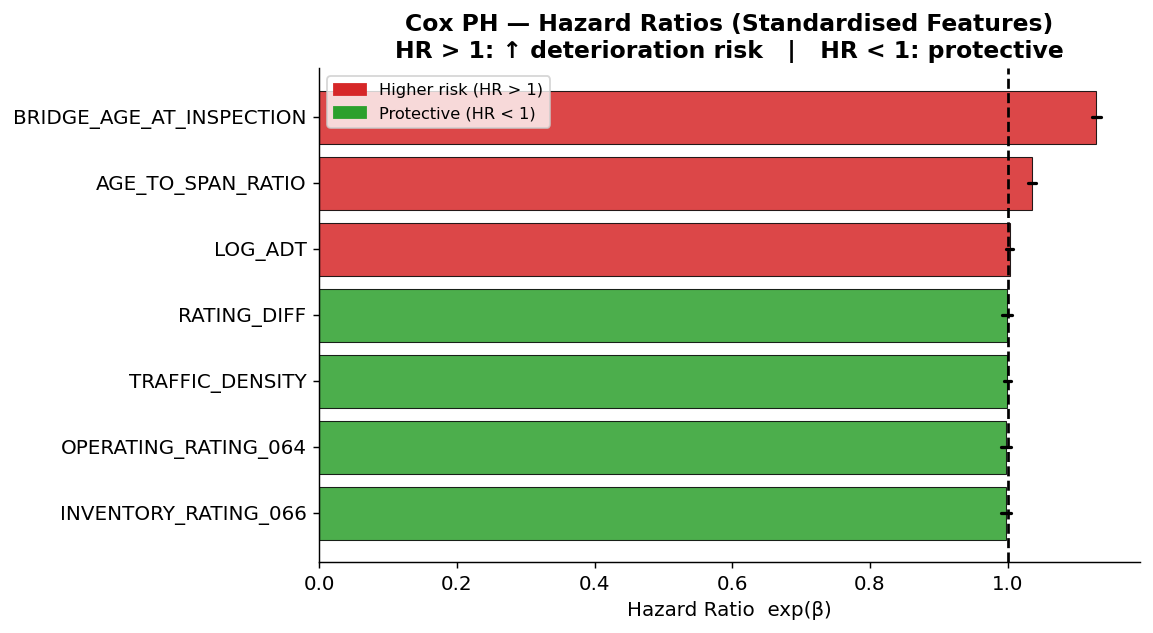


=== Proportional Hazards Assumption Check ===
(p < 0.05 suggests a violation — interpret Cox with caution)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'TRAFFIC_DENSITY' failed the non-proportional test: p-value is 0.0467.

   Advice 1: the functional form of the variable 'TRAFFIC_DENSITY' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'TRAFFIC_DENSITY' using pd.cut, and then specify it in
`strata=['TRAFFIC_DENSITY', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional

In [38]:
if LIFELINES_AVAILABLE and "cph" in dir() and cph is not None:
    summ = cph.summary.copy().sort_values("exp(coef)", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    hr_vals  = summ["exp(coef)"].values
    hr_lo    = summ.get("exp(coef) lower 95%", summ["exp(coef)"]).values
    hr_hi    = summ.get("exp(coef) upper 95%", summ["exp(coef)"]).values
    bar_cols = ["#d62728" if v > 1 else "#2ca02c" for v in hr_vals]

    bars = ax.barh(summ.index, hr_vals, color=bar_cols,
                   edgecolor="black", linewidth=0.6, alpha=0.85)
    for i, (lo, hi) in enumerate(zip(hr_lo, hr_hi)):
        ax.plot([lo, hi], [i, i], color="black", lw=1.8, solid_capstyle="round")

    ax.axvline(1.0, color="black", linestyle="--", lw=1.5)
    ax.set_xlabel("Hazard Ratio  exp(β)", fontsize=11)
    ax.set_title("Cox PH — Hazard Ratios (Standardised Features)\n"
                 "HR > 1: ↑ deterioration risk   |   HR < 1: protective",
                 fontweight="bold")

    hi_p = mpatches.Patch(color="#d62728", label="Higher risk (HR > 1)")
    lo_p = mpatches.Patch(color="#2ca02c", label="Protective (HR < 1)")
    ax.legend(handles=[hi_p, lo_p], fontsize=9)
    plt.tight_layout()
    plt.savefig("outputs/plots/20_cox_hazard_ratios.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── PH assumption check ───────────────────────────────────────────────────
    print("\n=== Proportional Hazards Assumption Check ===")
    print("(p < 0.05 suggests a violation — interpret Cox with caution)\n")
    try:
        cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
    except Exception as exc:
        print(f"  WARNING: Could not run assumption check: {exc}")


---
## Section 13 — Final Dashboard & Summary

A single publication-ready figure summarising all five analytical threads:
EDA → Drift → Model Performance → Survival → Hazard Ratios


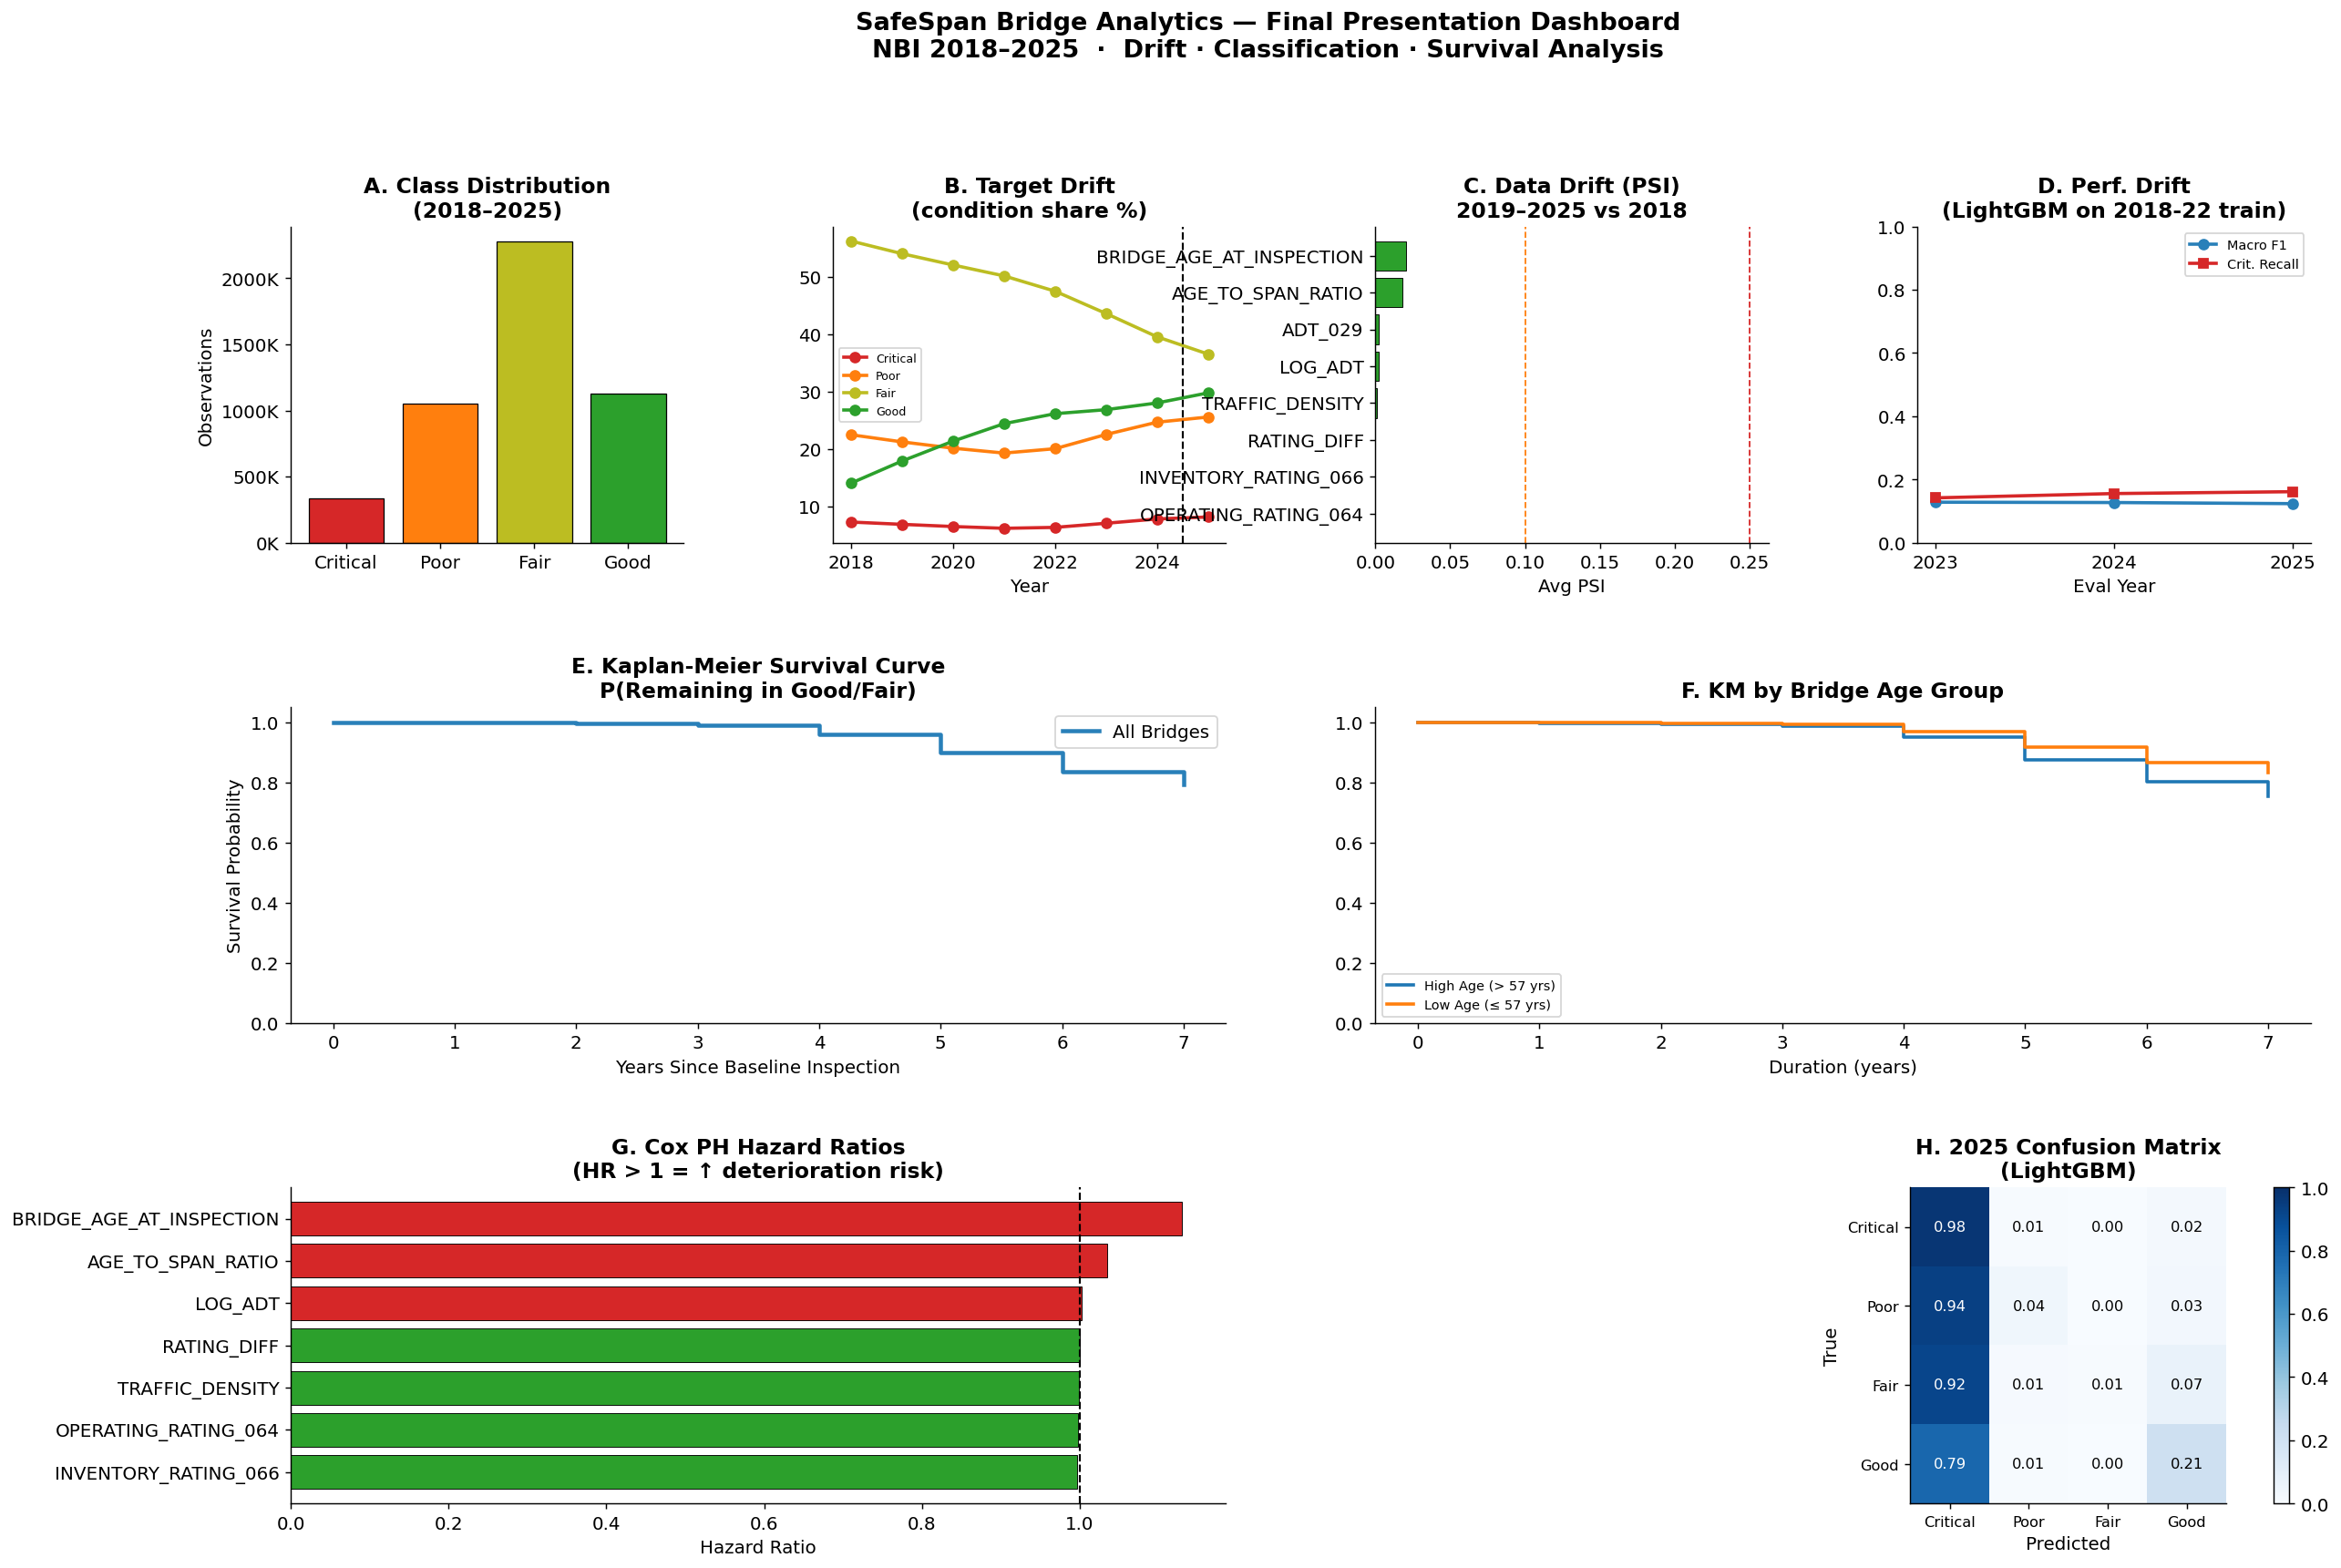

Saved: outputs/plots/00_FINAL_DASHBOARD.png


In [39]:
fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.38)

# ── Panel A: Class distribution ───────────────────────────────────────────────
axA = fig.add_subplot(gs[0, 0])
cnt = all_data["BRIDGE_CONDITION"].value_counts().reindex(CLASS_ORDER)
axA.bar(CLASS_ORDER, cnt.values,
        color=[CMAP[c] for c in CLASS_ORDER], edgecolor="black", lw=0.7)
axA.set_title("A. Class Distribution\n(2018–2025)", fontweight="bold")
axA.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axA.set_ylabel("Observations")

# ── Panel B: Target drift ─────────────────────────────────────────────────────
axB = fig.add_subplot(gs[0, 1])
for cond in CLASS_ORDER:
    axB.plot(pivot_td.index, pivot_td[cond],
             marker="o", color=CMAP[cond], label=cond, linewidth=2)
axB.axvline(2024.5, color="black", linestyle="--", lw=1.2)
axB.set_title("B. Target Drift\n(condition share %)", fontweight="bold")
axB.set_xlabel("Year");  axB.legend(fontsize=7)

# ── Panel C: PSI bar ─────────────────────────────────────────────────────────
axC = fig.add_subplot(gs[0, 2])
top8 = avg_psi.head(8)
bc2  = ["#d62728" if v >= 0.25 else "#ff7f0e" if v >= 0.10 else "#2ca02c"
        for v in top8.values]
axC.barh(top8.index[::-1], top8.values[::-1],
         color=bc2[::-1], edgecolor="black", lw=0.5)
axC.axvline(0.10, color="#ff7f0e", linestyle="--", lw=1)
axC.axvline(0.25, color="#d62728", linestyle="--", lw=1)
axC.set_xlabel("Avg PSI")
axC.set_title("C. Data Drift (PSI)\n2019–2025 vs 2018", fontweight="bold")

# ── Panel D: Performance drift ────────────────────────────────────────────────
axD = fig.add_subplot(gs[0, 3])
if len(perf_drift_df) >= 1:
    axD.plot(perf_drift_df["period"], perf_drift_df["macro_f1"],
             marker="o", color="#2980b9", label="Macro F1", linewidth=2)
    axD.plot(perf_drift_df["period"], perf_drift_df["critical_recall"],
             marker="s", color="#d62728", label="Crit. Recall", linewidth=2)
    axD.set_ylim(0, 1)
    axD.set_title(f"D. Perf. Drift\n({MODEL_NAME} on 2018-22 train)", fontweight="bold")
    axD.set_xlabel("Eval Year");  axD.legend(fontsize=8)

# ── Panel E: KM overall ───────────────────────────────────────────────────────
axE = fig.add_subplot(gs[1, 0:2])
if LIFELINES_AVAILABLE and "kmf" in dir():
    kmf.plot_survival_function(ax=axE, ci_show=True,
                               color="#2980b9", linewidth=2.5)
    axE.set_title("E. Kaplan-Meier Survival Curve\n"
                  "P(Remaining in Good/Fair)", fontweight="bold")
    axE.set_xlabel("Years Since Baseline Inspection")
    axE.set_ylabel("Survival Probability")
    axE.set_ylim(0, 1.05)
else:
    axE.text(0.5, 0.5, "lifelines\nnot installed",
             ha="center", va="center", transform=axE.transAxes,
             fontsize=12, color="grey")
    axE.set_title("E. Kaplan-Meier", fontweight="bold")

# ── Panel F: KM by age ───────────────────────────────────────────────────────
axF = fig.add_subplot(gs[1, 2:4])
if LIFELINES_AVAILABLE and "age_group" in survival_df.columns:
    for grp, color in [(f"High Age (> {age_med:.0f} yrs)", "#d62728"),
                       (f"Low Age (≤ {age_med:.0f} yrs)",  "#2ca02c")]:
        sub = survival_df[survival_df["age_group"] == grp]
        kmf_g2 = KaplanMeierFitter()
        kmf_g2.fit(sub["duration"], sub["event"], label=grp)
        kmf_g2.plot_survival_function(ax=axF, ci_show=False, linewidth=2)
    axF.set_title("F. KM by Bridge Age Group", fontweight="bold")
    axF.set_xlabel("Duration (years)")
    axF.set_ylim(0, 1.05);  axF.legend(fontsize=8)

# ── Panel G: Cox hazard ratios ────────────────────────────────────────────────
axG = fig.add_subplot(gs[2, 0:2])
if LIFELINES_AVAILABLE and "cph" in dir() and cph is not None:
    summ2 = cph.summary.sort_values("exp(coef)", ascending=True)
    cols2 = ["#d62728" if v > 1 else "#2ca02c" for v in summ2["exp(coef)"].values]
    axG.barh(summ2.index, summ2["exp(coef)"].values,
             color=cols2, edgecolor="black", lw=0.5)
    axG.axvline(1, color="black", linestyle="--", lw=1.2)
    axG.set_xlabel("Hazard Ratio")
    axG.set_title("G. Cox PH Hazard Ratios\n(HR > 1 = ↑ deterioration risk)",
                  fontweight="bold")

# ── Panel H: Confusion matrix (test 2025) ─────────────────────────────────────
axH = fig.add_subplot(gs[2, 2:4])
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
im = axH.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axH.set_xticks(range(4));  axH.set_yticks(range(4))
axH.set_xticklabels(CLASS_ORDER, fontsize=9)
axH.set_yticklabels(CLASS_ORDER, fontsize=9)
axH.set_xlabel("Predicted");  axH.set_ylabel("True")
axH.set_title(f"H. 2025 Confusion Matrix\n({MODEL_NAME})", fontweight="bold")
for i in range(4):
    for j in range(4):
        axH.text(j, i, f"{cm_norm[i,j]:.2f}",
                 ha="center", va="center", fontsize=9,
                 color="white" if cm_norm[i,j] > 0.5 else "black")
plt.colorbar(im, ax=axH, fraction=0.04)

fig.suptitle(
    "SafeSpan Bridge Analytics — Final Presentation Dashboard\n"
    "NBI 2018–2025  ·  Drift · Classification · Survival Analysis",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.savefig("outputs/plots/00_FINAL_DASHBOARD.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/00_FINAL_DASHBOARD.png")


---
## Summary of Results


In [40]:
print("=" * 65)
print("  SAFESPAN — FINAL RESULTS SUMMARY")
print("=" * 65)

print(f"\n{'─'*65}")
print("  1. DATA")
print(f"{'─'*65}")
print(f"  Training years  : 2018–2024  ({len(train_raw):,} rows)")
print(f"  Test year       : 2025        ({len(test_raw):,} rows)")
print(f"  Total bridges   : {all_data['STRUCTURE_NUMBER_008'].nunique():,} unique")
for c in CLASS_ORDER:
    n   = (all_data["BRIDGE_CONDITION"] == c).sum()
    pct = n / len(all_data) * 100
    print(f"    {c:<10s}: {n:>10,}  ({pct:.2f}%)")

print(f"\n{'─'*65}")
print("  2. DATA DRIFT (PSI, 2018 baseline)")
print(f"{'─'*65}")
sig = psi_df[psi_df["level"] == "significant"]
mod = psi_df[psi_df["level"] == "moderate"]
print(f"  Features with significant drift (PSI ≥ 0.25) : {sig['feature'].nunique()}")
print(f"  Features with moderate drift   (PSI 0.10–0.25): {mod['feature'].nunique()}")
print(f"  Top drifting feature : {avg_psi.index[0]}  (avg PSI = {avg_psi.iloc[0]:.4f})")

print(f"\n{'─'*65}")
print("  3. TARGET DRIFT")
print(f"{'─'*65}")
for c in CLASS_ORDER:
    delta = pivot_td.loc[2025, c] - pivot_td.loc[2018, c]
    print(f"    {c:<10s}: {pivot_td.loc[2018, c]:.2f}% → "
          f"{pivot_td.loc[2025, c]:.2f}%   Δ {delta:+.2f} pp")

print(f"\n{'─'*65}")
print(f"  4. MODEL PERFORMANCE ({MODEL_NAME}, trained 2018–2024)")
print(f"{'─'*65}")
print(f"  Macro F1             : {macro_f1:.4f}")
print(f"  Weighted F1          : {weighted_f1:.4f}")
print(f"  Accuracy             : {acc:.4f}")
print(f"  ROC-AUC (OvR macro)  : {roc_auc:.4f}")
print(f"  Critical Recall      : {crit_recall:.4f}")
print(f"  Critical→Good error  : {crit_to_good:.4f}  ← SAFETY METRIC")

if len(perf_drift_df) >= 2:
    print(f"\n{'─'*65}")
    print("  5. PERFORMANCE DRIFT (model trained on 2018-2022)")
    print(f"{'─'*65}")
    print(perf_drift_df[["period","macro_f1","critical_recall","critical_to_good"]]
          .to_string(index=False))

print(f"\n{'─'*65}")
print("  6. SURVIVAL ANALYSIS")
print(f"{'─'*65}")
print(f"  Bridges in survival dataset : {n_tot:,}")
print(f"  Observed events             : {n_event:,}  ({evt_rate:.1f}%)")
print(f"  Censored                    : {n_cens:,}  ({100-evt_rate:.1f}%)")
print(f"  Median observed duration    : {med_dur:.1f} years")
if LIFELINES_AVAILABLE and "kmf" in dir():
    print(f"  KM median survival time     : {kmf.median_survival_time_:.2f} years")

print(f"\n{'─'*65}")
print("  7. MULTI-MODEL BENCHMARK (500K sample)")
print(f"{'─'*65}")
if "bench_df" in dir():
    print(bench_df.to_string(index=False))

print(f"\n{'─'*65}")
print("  8. RISK RANKING")
print(f"{'─'*65}")
if "risk_df" in dir():
    print(f"  Bridges ranked: {len(risk_df):,}")
    print(f"  Top risk score: {risk_df['WEIGHTED_RISK'].max():.2f}")
    print(f"  Saved: outputs/bridge_risk_ranking.csv")

print(f"\n{'─'*65}")
print("  OUTPUT FILES")
print(f"{'─'*65}")
output_files = [
    "outputs/psi_numeric_drift.csv",
    "outputs/js_categorical_drift.csv",
    "outputs/target_drift_by_year.csv",
    "outputs/test_2025_metrics.csv",
    "outputs/model_performance_drift.csv",
    "outputs/survival_dataset.csv",
    "outputs/cox_hazard_summary.csv",
    "outputs/benchmark_comparison.csv",
    "outputs/bridge_risk_ranking.csv",
    "outputs/plots/00_FINAL_DASHBOARD.png",
    "outputs/plots/01_class_distribution.png",
    "outputs/plots/02_yearly_condition_trend.png",
    "outputs/plots/03_age_by_condition.png",
    "outputs/plots/04_condition_by_material.png",
    "outputs/plots/05_adt_by_condition.png",
    "outputs/plots/06_state_critical_rate.png",
    "outputs/plots/07_engineered_features.png",
    "outputs/plots/08_psi_drift.png",
    "outputs/plots/09_js_drift.png",
    "outputs/plots/10_target_drift.png",
    "outputs/plots/11_confusion_matrix.png",
    "outputs/plots/12_prob_distributions.png",
    "outputs/plots/12b_calibration_curves.png",
    "outputs/plots/13_shap_importance.png",
    "outputs/plots/14_shap_beeswarm_critical.png",
    "outputs/plots/15_model_performance_drift.png",
    "outputs/plots/16_km_overall.png",
    "outputs/plots/17_km_by_age.png",
    "outputs/plots/18_km_by_material.png",
    "outputs/plots/19_km_by_rating_gap.png",
    "outputs/plots/20_cox_hazard_ratios.png",
]
for f in output_files:
    mark = "[done]" if os.path.exists(f) else "  "
    print(f"  {mark} {f}")

print("=" * 65)
print("  SafeSpan — DATA 245 Final Presentation Complete")
print("=" * 65)


  SAFESPAN — FINAL RESULTS SUMMARY

─────────────────────────────────────────────────────────────────
  1. DATA
─────────────────────────────────────────────────────────────────
  Training years  : 2018–2024  (4,200,000 rows)
  Test year       : 2025        (600,000 rows)
  Total bridges   : 600,000 unique
    Critical  :    336,569  (7.01%)
    Poor      :  1,055,395  (21.99%)
    Fair      :  2,277,380  (47.45%)
    Good      :  1,130,656  (23.56%)

─────────────────────────────────────────────────────────────────
  2. DATA DRIFT (PSI, 2018 baseline)
─────────────────────────────────────────────────────────────────
  Features with significant drift (PSI ≥ 0.25) : 0
  Features with moderate drift   (PSI 0.10–0.25): 0
  Top drifting feature : BRIDGE_AGE_AT_INSPECTION  (avg PSI = 0.0206)

─────────────────────────────────────────────────────────────────
  3. TARGET DRIFT
─────────────────────────────────────────────────────────────────
    Critical  : 7.26% → 8.14%   Δ +0.88 pp
    Poor